# Datathon 2026 by Artificial Intelligence and Technology Academy
# Cognitive Performance Score Prediction

## Approach Overview
### This notebook includes merging datathon training set with an external dataset to increase training data size. The pipeline includes:
- Data harmonization,
- Missin value imputation via classifier models,
- Sentence embedding + PCA for categorical text features,
- CatBoost regression with Optuna hyperparameter tuning

The external dataset Ive used is --> [External Dataset](http://www.kaggle.com/datasets/mohankrishnathalla/sleep-health-and-daily-performance-dataset/)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
train=pd.read_csv('/kaggle/input/competitions/yzta-2026-datathon/train.csv')
test=pd.read_csv('/kaggle/input/competitions/yzta-2026-datathon/test_x.csv')
ext=pd.read_csv('/kaggle/input/datasets/mohankrishnathalla/sleep-health-and-daily-performance-dataset/sleep_health_dataset.csv')#This dataset comes from kaggle independently from competition

# Exploratory Data Analysis (EDA)

In [3]:
train.dtypes

id                               int64
yas                              int64
cinsiyet                        object
meslek                          object
vucut_kitle_indeksi            float64
ulke                            object
rem_yuzdesi                    float64
derin_uyku_yuzdesi             float64
uykuya_dalma_suresi_dk           int64
gecelik_uyanma_sayisi            int64
uyku_oncesi_kafein_mg          float64
uyku_oncesi_ekran_suresi_dk      int64
gunluk_adim_sayisi               int64
sekerleme_suresi_dk              int64
stres_skoru                    float64
gunluk_calisma_saati           float64
kronotip                        object
ruh_sagligi_durumu              object
dinlenik_nabiz_bpm               int64
oda_sicakligi_celsius          float64
hafta_sonu_uyku_farki_saat     float64
mevsim                          object
gun_tipi                        object
bilissel_performans_skoru      float64
dtype: object

In [4]:
ext.dtypes

person_id                        int64
age                              int64
gender                          object
occupation                      object
bmi                            float64
country                         object
sleep_duration_hrs             float64
sleep_quality_score            float64
rem_percentage                 float64
deep_sleep_percentage          float64
sleep_latency_mins               int64
wake_episodes_per_night          int64
caffeine_mg_before_bed           int64
alcohol_units_before_bed       float64
screen_time_before_bed_mins      int64
exercise_day                     int64
steps_that_day                   int64
nap_duration_mins                int64
stress_score                   float64
work_hours_that_day            float64
chronotype                      object
mental_health_condition         object
heart_rate_resting_bpm           int64
sleep_aid_used                   int64
shift_work                       int64
room_temperature_celsius 

### As we see these two dataset almost completely same as a columns. However for now the first thing we see obviously is between these two dataset there is some columns not fits to the original dataset (which is the datathons dataset) and the other one is language mismatch.

In [5]:
#We do want to implement the external data to our datathon thats why I am going to convert original dataset to english
train.columns

Index(['id', 'yas', 'cinsiyet', 'meslek', 'vucut_kitle_indeksi', 'ulke',
       'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk',
       'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg',
       'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi',
       'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati',
       'kronotip', 'ruh_sagligi_durumu', 'dinlenik_nabiz_bpm',
       'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat', 'mevsim',
       'gun_tipi', 'bilissel_performans_skoru'],
      dtype='object')

In [6]:
ext.columns

Index(['person_id', 'age', 'gender', 'occupation', 'bmi', 'country',
       'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage',
       'deep_sleep_percentage', 'sleep_latency_mins',
       'wake_episodes_per_night', 'caffeine_mg_before_bed',
       'alcohol_units_before_bed', 'screen_time_before_bed_mins',
       'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score',
       'work_hours_that_day', 'chronotype', 'mental_health_condition',
       'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work',
       'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'season',
       'day_type', 'cognitive_performance_score', 'sleep_disorder_risk',
       'felt_rested'],
      dtype='object')

# Data Harmonization

In [7]:
train_to_eng = {
    "id": "person_id",
    "yas": "age",
    "cinsiyet": "gender",
    "meslek": "occupation",
    "vucut_kitle_indeksi": "bmi",
    "ulke": "country",
    "rem_yuzdesi": "rem_percentage",
    "derin_uyku_yuzdesi": "deep_sleep_percentage",
    "uykuya_dalma_suresi_dk": "sleep_latency_mins",
    "gecelik_uyanma_sayisi": "wake_episodes_per_night",
    "uyku_oncesi_kafein_mg": "caffeine_mg_before_bed",
    "uyku_oncesi_ekran_suresi_dk": "screen_time_before_bed_mins",
    "gunluk_adim_sayisi": "steps_that_day",
    "sekerleme_suresi_dk": "nap_duration_mins",
    "stres_skoru": "stress_score",
    "gunluk_calisma_saati": "work_hours_that_day",
    "kronotip": "chronotype",
    "ruh_sagligi_durumu": "mental_health_condition",
    "dinlenik_nabiz_bpm": "heart_rate_resting_bpm",
    "oda_sicakligi_celsius": "room_temperature_celsius",
    "hafta_sonu_uyku_farki_saat": "weekend_sleep_diff_hrs",
    "mevsim": "season",
    "gun_tipi": "day_type",
    "bilissel_performans_skoru": "cognitive_performance_score"
}

In [8]:
train=train.rename(columns=train_to_eng)

In [9]:
pd.set_option('display.max_columns', None)
train.head()

,person_id,age,gender,occupation,bmi,country,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,screen_time_before_bed_mins,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,heart_rate_resting_bpm,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score
0,1,34,Erkek,Saglik Personeli,31.470103,Cin,14.431210,14.645436,27,7,0.0,97,7184,0,9.922976,10.045274,Sabah insani,Anksiyete ve depresyon,78,18.962436,-0.074140,Sonbahar-Kis,Hafta ici,0.136441
1,2,32,Kadin,Muhendis,30.981394,Amerika,21.771870,27.220360,20,4,4.0,180,5057,1,6.626400,6.319245,Gece insani,Saglikli,76,21.225666,0.942672,Sonbahar-Kis,Hafta ici,5.848312
2,3,39,Erkek,Ev Hanimi,21.533898,Spain,18.178857,25.530104,33,7,148.0,23,10816,70,6.093566,3.824463,Notr,Depresyon,66,18.482409,1.239886,Ilkbahar-Yaz,Hafta sonu,6.828276
3,4,40,Kadin,Egitimci,23.310749,Yeni Zelanda,21.438151,15.891188,21,2,0.0,180,5238,115,3.168185,4.597316,Gece insani,Saglikli,60,21.862235,0.727695,Sonbahar-Kis,Hafta sonu,8.144649
4,5,36,Kadin,NaN,NaN,Portekiz,25.468018,16.356738,21,8,100.0,145,4042,0,7.198574,3.189120,Notr,Anksiyete ve depresyon,74,19.223195,-0.223402,Sonbahar-Kis,Hafta ici,0.431423


In [10]:
ext.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,16,3,0,0.0,32,0,6592,0,4.4,10.7,Morning,Healthy,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,17,4,0,0.0,33,1,10111,8,4.0,3.0,Neutral,Healthy,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,26,4,0,2.0,89,1,9222,28,7.8,3.6,Neutral,Both,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,13,4,0,1.0,52,1,9190,40,4.9,6.7,Morning,Healthy,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,30,5,40,0.0,72,0,4273,0,7.4,10.4,Neutral,Healthy,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [11]:
train['Source'] = 'Train'
ext['Source'] = 'External'
#It was for the understand which row comes from where for further applications.

In [12]:
com_cols=list(set(train.columns).intersection(set(ext.columns)))
print(len(com_cols))

25


### Okey we handled the column names but we had to handle also the variables in the column they has to match

In [13]:
print(f"Gender {train['gender'].nunique()}")
print(f"Occupation {train['occupation'].nunique()}")
print(f"Country {train['country'].nunique()}")
print(f"Chronotype {train['chronotype'].nunique()}")
print(f"Mental Health Condition {train['mental_health_condition'].nunique()}")
print(f"Season {train['season'].nunique()}")
print(f"Day Type {train['day_type'].nunique()}")

Gender 2
Occupation 11
Country 15
Chronotype 3
Mental Health Condition 4
Season 2
Day Type 2


In [14]:
print(f"Gender {ext['gender'].nunique()}")
print(f"Occupation {ext['occupation'].nunique()}")
print(f"Country {ext['country'].nunique()}")
print(f"Chronotype {ext['chronotype'].nunique()}")
print(f"Mental Health Condition {ext['mental_health_condition'].nunique()}")
print(f"Season {ext['season'].nunique()}")
print(f"Day Type {ext['day_type'].nunique()}")

Gender 3
Occupation 12
Country 15
Chronotype 3
Mental Health Condition 4
Season 4
Day Type 2


In [15]:
#Since there is 3 gender in external source we will remove the 3rd one
ext['gender'].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [16]:
ext.drop(ext[ext['gender'] == 'Other'].index, inplace=True)

In [17]:
#After being sure there is only two gender value in the column I am translating them also into english
train["gender"] = train["gender"].replace({
    "Kadin": "Female",
    "Erkek": "Male"
})

In [18]:
#Since there is 3 gender in external source we will remove the 3rd one
ext['occupation'].unique()

array(['Driver', 'Software Engineer', 'Nurse', 'Student', 'Lawyer',
       'Freelancer', 'Manager', 'Doctor', 'Homemaker', 'Teacher',
       'Retired', 'Sales'], dtype=object)

In [19]:
#Since there is 3 gender in external source we will remove the 3rd one
train['occupation'].unique()

array(['Saglik Personeli', 'Muhendis', 'Ev Hanimi', 'Egitimci', nan,
       'Satis ve Pazarlama Calisani', 'Yonetici', 'Lawyer', 'Emekli',
       'Ogrenci', 'Lojistik Calisani', 'Serbest Calisan'], dtype=object)

In [20]:
#Therre is 2 variable at the external data thats why we can reduce it to 1 like healthcare service

In [21]:
occupation_to_eng = {
    "Saglik Personeli": "Healthcare personnel",
    "Muhendis": "Engineer",
    "Ev Hanimi": "Homemaker",
    "Egitimci": "Teacher",
    "Satis ve Pazarlama Calisani": "Sales",
    "Yonetici": "Manager",
    "Emekli": "Retired",
    "Ogrenci": "Student",
    "Lojistik Calisani": "Driver",
    "Serbest Calisan": "Freelancer"
}

train["occupation"] = train["occupation"].replace(occupation_to_eng)

In [22]:
occupation_to_common = {
    "Nurse": "Healthcare personnel",
    "Doctor": "Healthcare personnel",#Both value is transfared to Healthcare personnel due to not lose data also this both value is very similar to each other
    "Software Engineer": "Engineer"
}

ext["occupation"] = ext["occupation"].replace(occupation_to_common)

In [23]:
ext['country'].unique()

array(['Japan', 'USA', 'India', 'Spain', 'Brazil', 'Netherlands', 'UK',
       'Germany', 'South Korea', 'Australia', 'Canada', 'Italy', 'France',
       'Sweden', 'Mexico'], dtype=object)

In [24]:
train['country'].unique()

array(['Cin', 'Amerika', 'Spain', 'Yeni Zelanda', 'Portekiz',
       'South Korea', 'Fransa', 'Ispanya', 'Ingiltere', 'Netherlands',
       'Arjantin', 'Guney Kore', 'Isvec', 'Sweden', 'Mexico'],
      dtype=object)

In [25]:
country_to_eng = {
    "Cin": "China",
    "Amerika": "USA",
    "Spain": "Spain",
    "Yeni Zelanda": "New Zealand",
    "Portekiz": "Portugal",
    "South Korea": "South Korea",
    "Fransa": "France",
    "Ispanya": "Spain",
    "Ingiltere": "USA",##
    "Netherlands": "Netherlands",
    "Arjantin": "Argentina",
    "Guney Kore": "South Korea",
    "Isvec": "Sweden",
    "Sweden": "Sweden",
    "Mexico": "Mexico"
}
train["country"] = train["country"].replace(country_to_eng)

In [26]:
ext_to_most_common = {
    "Japan": "South Korea",
    "India": "China",
    "Brazil": "Argentina",
    "Germany": "France", # Train'de karşılığı daha dengeli bir ülke seçilmeli
    "Australia": "New Zealand",
    "Canada": "Sweden",
    "Italy": "Portugal",
    "USA": "USA",
    "UK": "USA",##
    "France":"Spain"
}

ext["country"] = ext["country"].replace(ext_to_most_common)

In [27]:
train['country'].unique()

array(['China', 'USA', 'Spain', 'New Zealand', 'Portugal', 'South Korea',
       'France', 'Netherlands', 'Argentina', 'Sweden', 'Mexico'],
      dtype=object)

In [28]:
ext['country'].unique()

array(['South Korea', 'USA', 'China', 'Spain', 'Argentina', 'Netherlands',
       'France', 'New Zealand', 'Sweden', 'Portugal', 'Mexico'],
      dtype=object)

In [29]:
ext['chronotype'].unique()

array(['Morning', 'Neutral', 'Evening'], dtype=object)

In [30]:
train['chronotype'].unique()

array(['Sabah insani', 'Gece insani', 'Notr', nan], dtype=object)

In [31]:
chrono_to_eng={
    "Sabah insani":"Morning",
    "Gece insani":"Evening",
    "Notr":"Neutral"
}
train["chronotype"] = train["chronotype"].replace(chrono_to_eng)

In [32]:
train['chronotype'].unique()

array(['Morning', 'Evening', 'Neutral', nan], dtype=object)

In [33]:
train['mental_health_condition'].unique()

array(['Anksiyete ve depresyon', 'Saglikli', 'Depresyon', 'Anksiyete',
       nan], dtype=object)

In [34]:
ext['mental_health_condition'].unique()

array(['Healthy', 'Both', 'Depression', 'Anxiety'], dtype=object)

In [35]:
mental_to_eng={
    "Saglikli":"Healthy",
    "Depresyon":"Depression",
    "Anksiyete":"Anxiety",
    "Anksiyete ve depresyon":"Both"
}
train["mental_health_condition"] = train["mental_health_condition"].replace(mental_to_eng)

In [36]:
train['mental_health_condition'].unique()

array(['Both', 'Healthy', 'Depression', 'Anxiety', nan], dtype=object)

In [37]:
train['season'].unique()

array(['Sonbahar-Kis', 'Ilkbahar-Yaz'], dtype=object)

In [38]:
ext['season'].unique()

array(['Autumn', 'Winter', 'Spring', 'Summer'], dtype=object)

In [39]:
season_to_eng={
    "Sonbahar-Kis":"Autumn-Winter",
    "Ilkbahar-Yaz":"Spring-Summer"
}
train["season"] = train["season"].replace(season_to_eng)

In [40]:
ext_season_to_common={
    "Autumn":"Autumn-Winter",
    "Winter":"Autumn-Winter",
    "Spring":"Spring-Summer",
    "Summer":"Spring-Summer"
}
ext["season"] = ext["season"].replace(ext_season_to_common)

In [41]:
train['day_type'].unique()

array(['Hafta ici', 'Hafta sonu'], dtype=object)

In [42]:
ext['day_type'].unique()

array(['Weekday', 'Weekend'], dtype=object)

In [43]:
dayt_to_eng={
    "Hafta ici":"Weekday",
    "Hafta sonu":"Weekend"
}
train["day_type"] = train["day_type"].replace(dayt_to_eng)

### Okey we have done converting all the variables to the english.

## Time to see what is misssing and what is similar between these two dataset.

In [44]:
train.isnull().sum()

person_id                         0
age                               0
gender                            0
occupation                     1378
bmi                            1752
country                           0
rem_percentage                    0
deep_sleep_percentage             0
sleep_latency_mins                0
wake_episodes_per_night           0
caffeine_mg_before_bed         1463
screen_time_before_bed_mins       0
steps_that_day                    0
nap_duration_mins                 0
stress_score                   1715
work_hours_that_day               0
chronotype                     1968
mental_health_condition        1096
heart_rate_resting_bpm            0
room_temperature_celsius          0
weekend_sleep_diff_hrs            0
season                            0
day_type                          0
cognitive_performance_score       0
Source                            0
dtype: int64

In [45]:
train.isnull().mean()*100

person_id                      0.000000
age                            0.000000
gender                         0.000000
occupation                     2.460714
bmi                            3.128571
country                        0.000000
rem_percentage                 0.000000
deep_sleep_percentage          0.000000
sleep_latency_mins             0.000000
wake_episodes_per_night        0.000000
caffeine_mg_before_bed         2.612500
screen_time_before_bed_mins    0.000000
steps_that_day                 0.000000
nap_duration_mins              0.000000
stress_score                   3.062500
work_hours_that_day            0.000000
chronotype                     3.514286
mental_health_condition        1.957143
heart_rate_resting_bpm         0.000000
room_temperature_celsius       0.000000
weekend_sleep_diff_hrs         0.000000
season                         0.000000
day_type                       0.000000
cognitive_performance_score    0.000000
Source                         0.000000


###These percentages not so big we can easily handle these missing values

In [46]:
ext.isnull().sum()

person_id                      0
age                            0
gender                         0
occupation                     0
bmi                            0
country                        0
sleep_duration_hrs             0
sleep_quality_score            0
rem_percentage                 0
deep_sleep_percentage          0
sleep_latency_mins             0
wake_episodes_per_night        0
caffeine_mg_before_bed         0
alcohol_units_before_bed       0
screen_time_before_bed_mins    0
exercise_day                   0
steps_that_day                 0
nap_duration_mins              0
stress_score                   0
work_hours_that_day            0
chronotype                     0
mental_health_condition        0
heart_rate_resting_bpm         0
sleep_aid_used                 0
shift_work                     0
room_temperature_celsius       0
weekend_sleep_diff_hrs         0
season                         0
day_type                       0
cognitive_performance_score    0
sleep_diso

###Excellent unlikely to our datathon dataset, our external dataset has no missing value.

##Lets Compare of the distribution of these two dataset see if they fit or not

In [47]:
import seaborn as sns

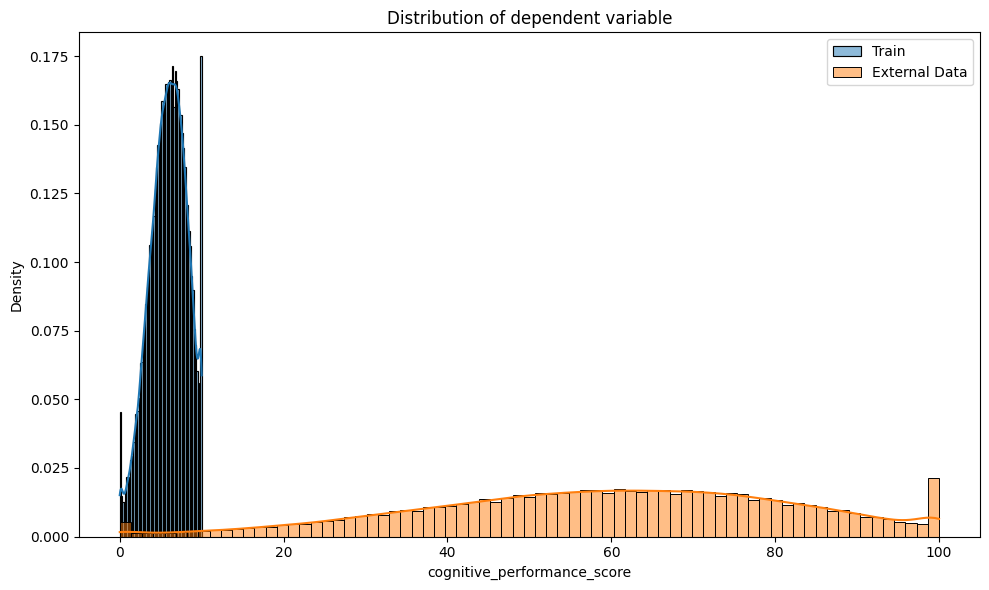

Train Target Min-Max: 0.0 - 10.0
External Target Min-Max: 0.0 - 100.0


In [48]:
target = 'cognitive_performance_score'
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(train[target].dropna(), label='Train', stat='density', kde=True, ax=ax)
sns.histplot(ext[target].dropna(), label='External Data', stat='density', kde=True, ax=ax)

ax.set_title('Distribution of dependent variable')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Train Target Min-Max: {train[target].min()} - {train[target].max()}")
print(f"External Target Min-Max: {ext[target].min()} - {ext[target].max()}")

### What we face with is horrible as we see but there is a huge gap between our train data target range and external data range so we need to make simplifications and rerun the code see what they are really like when their ratio is balanced to each other

In [49]:
ext['cognitive_performance_score']=ext['cognitive_performance_score'] / 10

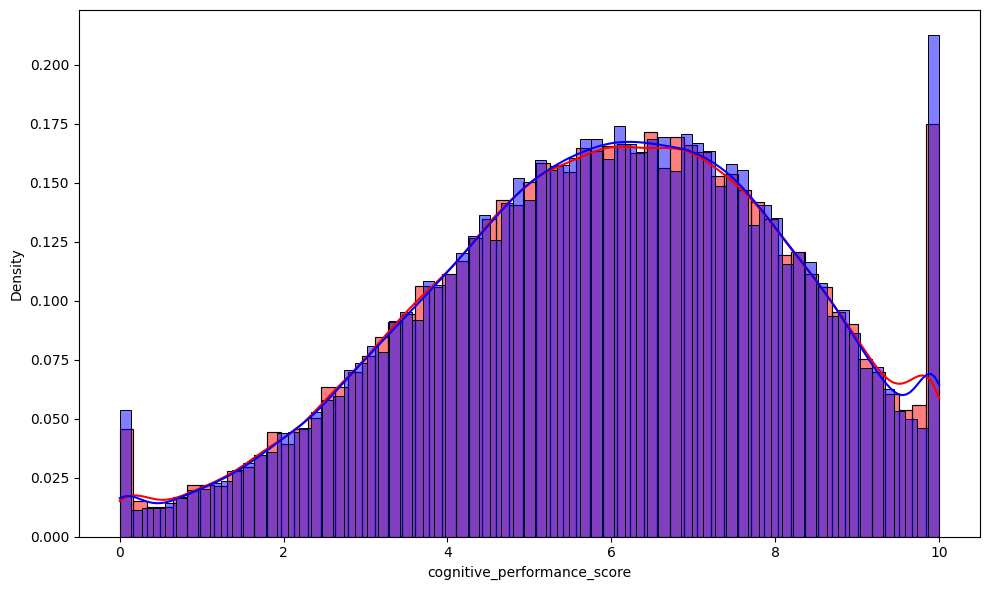

Train Target Min-Max: 0.0 - 10.0
External Target Min-Max: 0.0 - 10.0


In [50]:
target = 'cognitive_performance_score'
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(train[target].dropna(),
             label='Train',
             stat='density',
             color='red',
             alpha=0.5,
             kde=True,
             ax=ax)

sns.histplot(ext[target].dropna(),
             label='External Data',
             stat='density',
             color='blue',
             alpha=0.5,
             kde=True,
             ax=ax)

plt.tight_layout()
plt.show()

print(f"Train Target Min-Max: {train[target].min()} - {train[target].max()}")
print(f"External Target Min-Max: {ext[target].min()} - {ext[target].max()}")

## Okey it seems like these both dataset is SOOO SIMILAR ALMOST THE SAME.
But what about other columns=?

In [51]:
df_combined=pd.concat([train,ext], ignore_index=True)

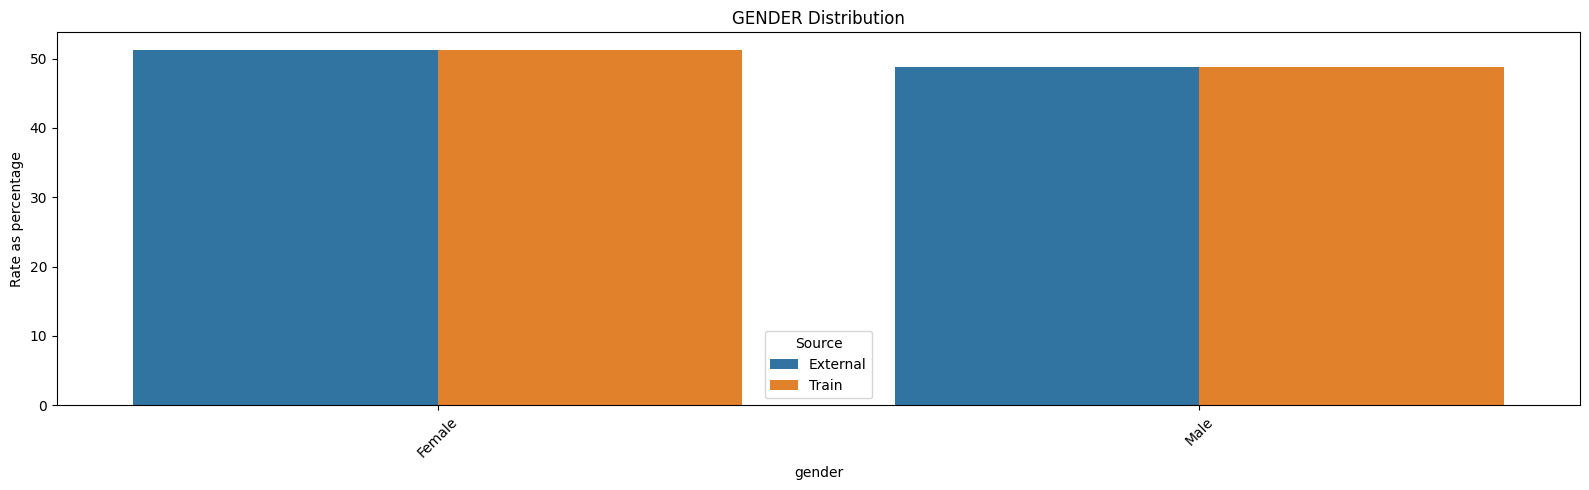

In [52]:
plt.figure(figsize=(16, 5))

prop_df = (
    df_combined.groupby('Source')['gender']
    .value_counts(normalize=True)
    .rename('Percentage')
    .reset_index()
)

prop_df['Percentage'] *= 100

sns.barplot(
    data=prop_df,
    x='gender',
    y='Percentage',
    hue='Source'
)

plt.title('GENDER Distribution')
plt.xticks(rotation=45)
plt.ylabel('Rate as percentage')
plt.tight_layout()

plt.show()

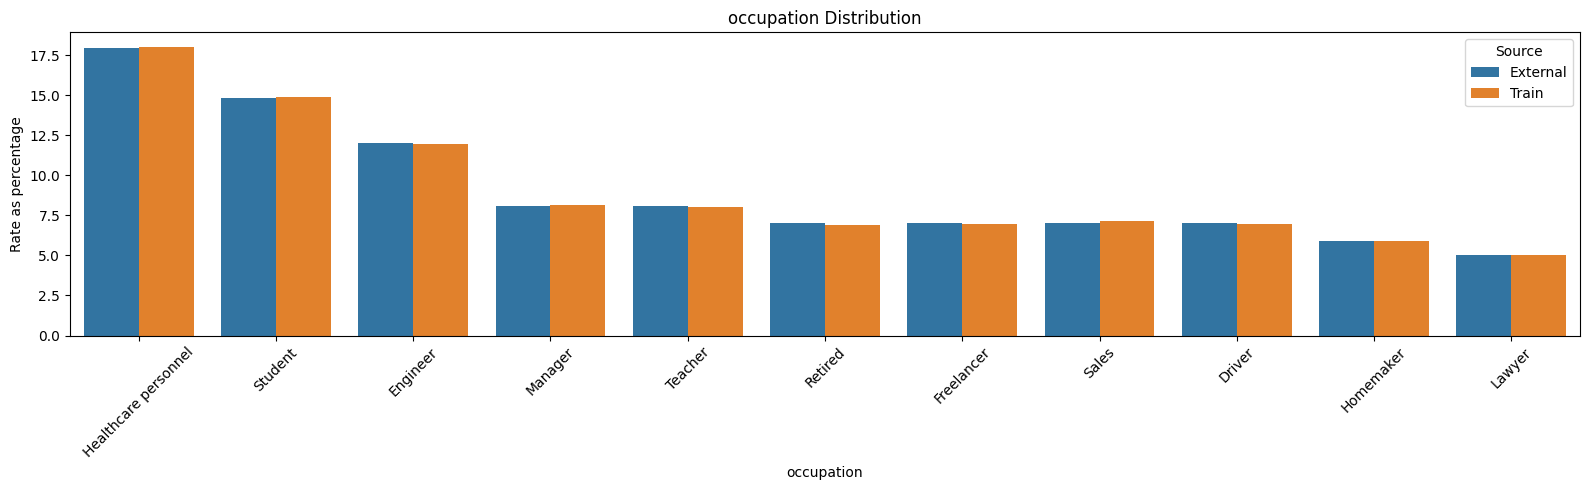

In [53]:
plt.figure(figsize=(16, 5))

prop_df = (
    df_combined.groupby('Source')['occupation']
    .value_counts(normalize=True)
    .rename('Percentage')
    .reset_index()
)

prop_df['Percentage'] *= 100

sns.barplot(
    data=prop_df,
    x='occupation',
    y='Percentage',
    hue='Source'
)

plt.title('occupation Distribution')
plt.xticks(rotation=45)
plt.ylabel('Rate as percentage')
plt.tight_layout()

plt.show()

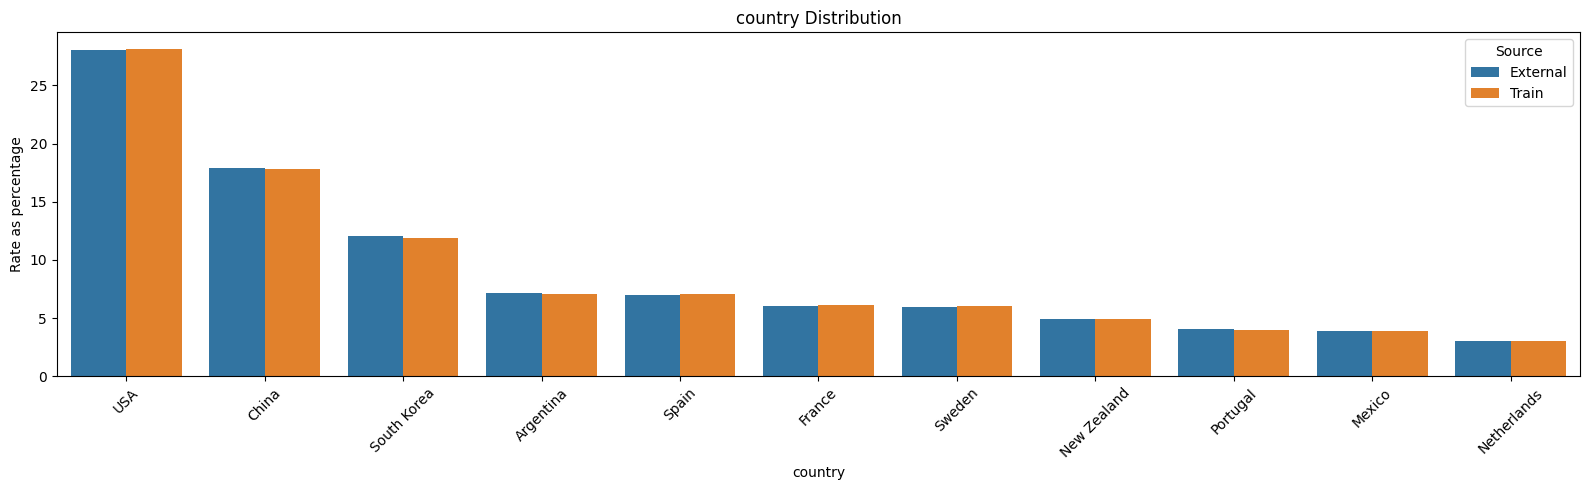

In [54]:
plt.figure(figsize=(16, 5))

prop_df = (
    df_combined.groupby('Source')['country']
    .value_counts(normalize=True)
    .rename('Percentage')
    .reset_index()
)

prop_df['Percentage'] *= 100

sns.barplot(
    data=prop_df,
    x='country',
    y='Percentage',
    hue='Source'
)

plt.title('country Distribution')
plt.xticks(rotation=45)
plt.ylabel('Rate as percentage')
plt.tight_layout()

plt.show()

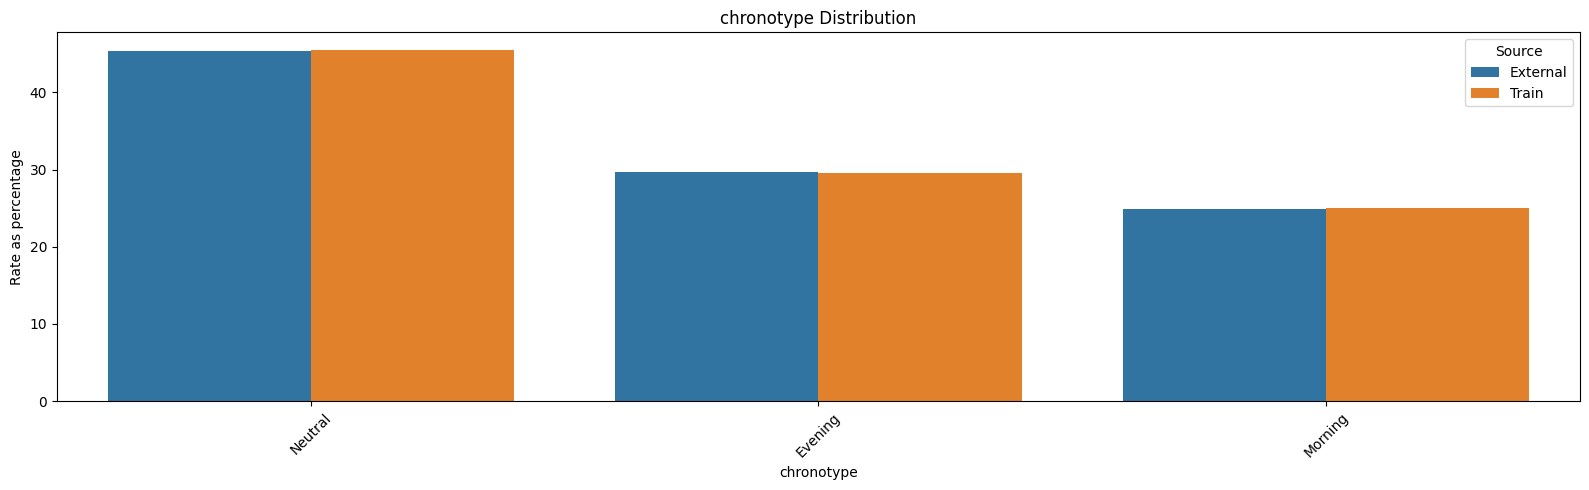

In [55]:
plt.figure(figsize=(16, 5))

prop_df = (
    df_combined.groupby('Source')['chronotype']
    .value_counts(normalize=True)
    .rename('Percentage')
    .reset_index()
)

prop_df['Percentage'] *= 100

sns.barplot(
    data=prop_df,
    x='chronotype',
    y='Percentage',
    hue='Source'
)

plt.title('chronotype Distribution')
plt.xticks(rotation=45)
plt.ylabel('Rate as percentage')
plt.tight_layout()

plt.show()

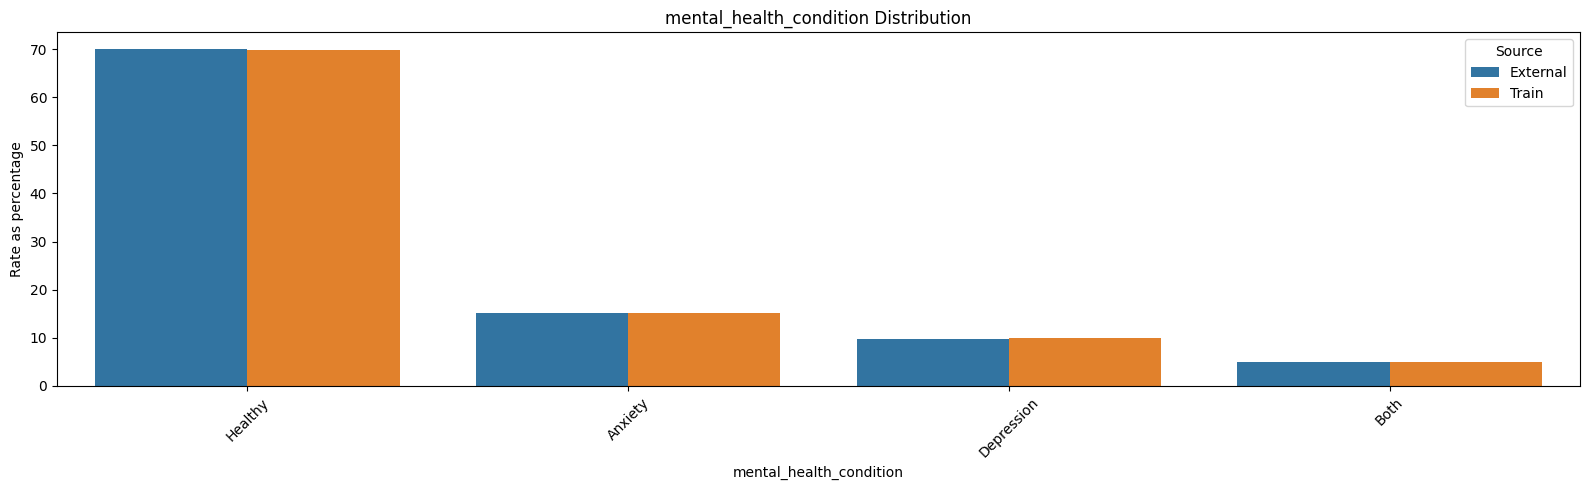

In [56]:
plt.figure(figsize=(16, 5))

prop_df = (
    df_combined.groupby('Source')['mental_health_condition']
    .value_counts(normalize=True)
    .rename('Percentage')
    .reset_index()
)

prop_df['Percentage'] *= 100

sns.barplot(
    data=prop_df,
    x='mental_health_condition',
    y='Percentage',
    hue='Source'
)

plt.title('mental_health_condition Distribution')
plt.xticks(rotation=45)
plt.ylabel('Rate as percentage')
plt.tight_layout()

plt.show()

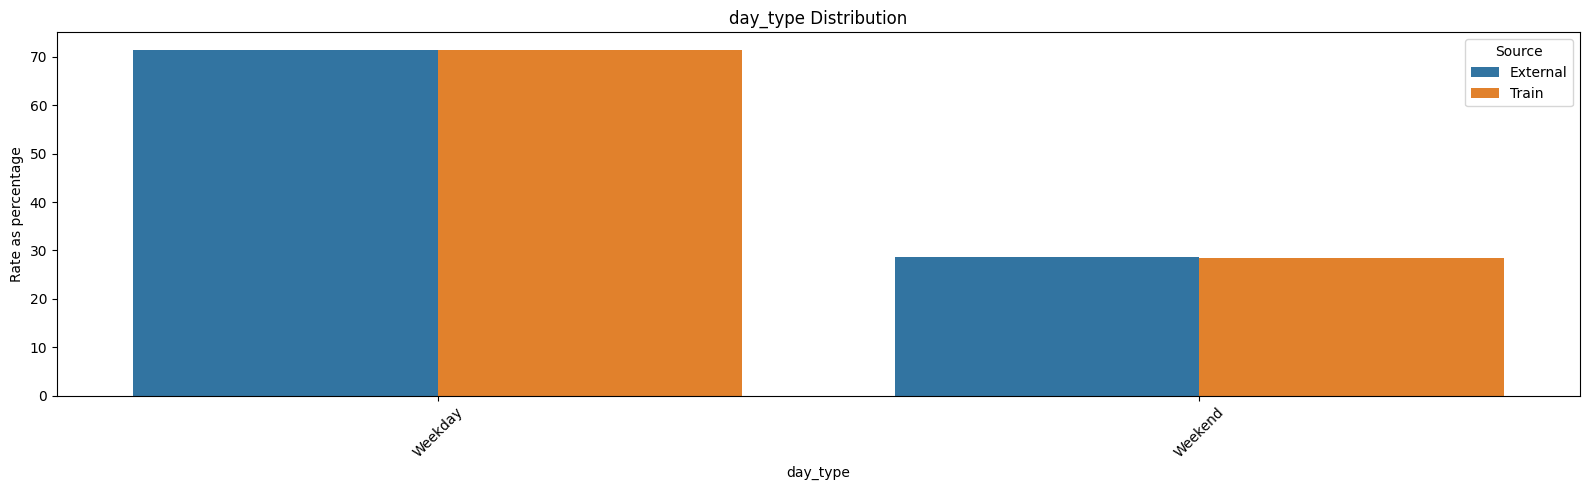

In [57]:
plt.figure(figsize=(16, 5))

prop_df = (
    df_combined.groupby('Source')['day_type']
    .value_counts(normalize=True)
    .rename('Percentage')
    .reset_index()
)

prop_df['Percentage'] *= 100

sns.barplot(
    data=prop_df,
    x='day_type',
    y='Percentage',
    hue='Source'
)

plt.title('day_type Distribution')
plt.xticks(rotation=45)
plt.ylabel('Rate as percentage')
plt.tight_layout()

plt.show()

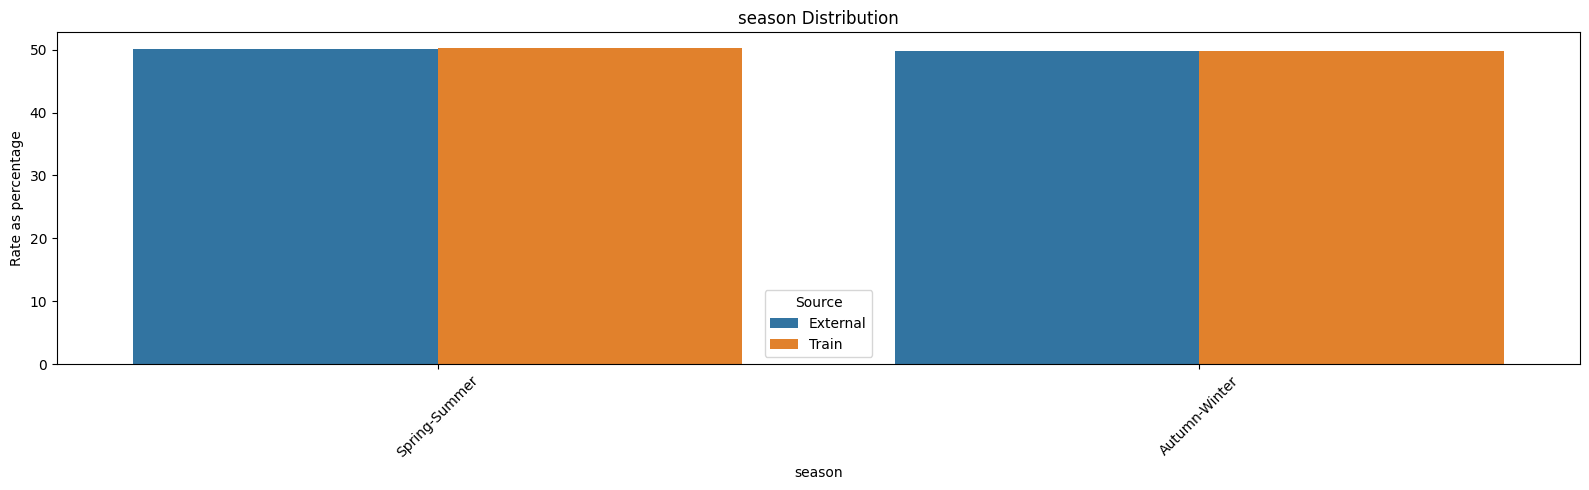

In [58]:
plt.figure(figsize=(16, 5))

prop_df = (
    df_combined.groupby('Source')['season']
    .value_counts(normalize=True)
    .rename('Percentage')
    .reset_index()
)

prop_df['Percentage'] *= 100

sns.barplot(
    data=prop_df,
    x='season',
    y='Percentage',
    hue='Source'
)

plt.title('season Distribution')
plt.xticks(rotation=45)
plt.ylabel('Rate as percentage')
plt.tight_layout()

plt.show()

### Lucky for us the distribitution of the both dataset is very similar that shows we can implement the external data to our data.

In [59]:
from scipy import stats

KS Statistic: 0.0030481402893109966
P-Value: 0.893994380789672
Aynı dağılım mı?: True


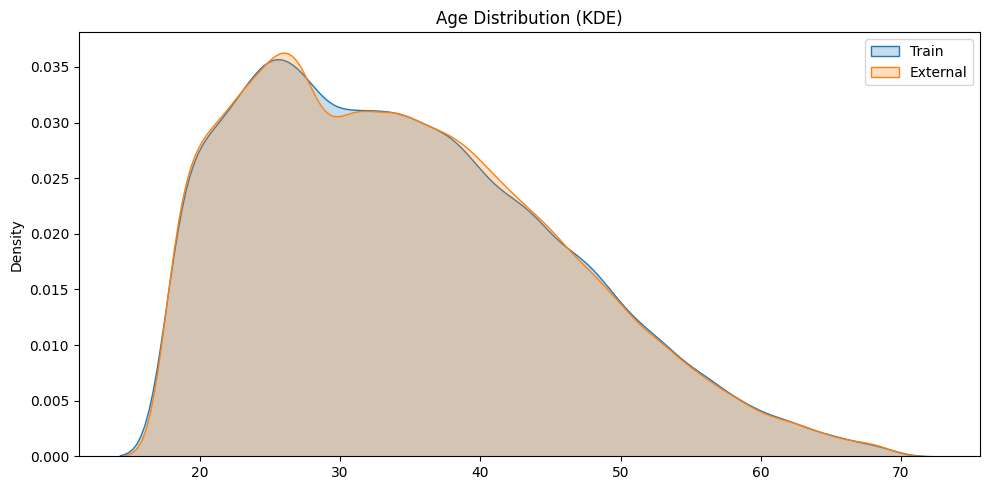

In [60]:
t_vals = train['age'].dropna().values
ext_vals = ext['age'].dropna().values

# KS TEST
stat, p_val = stats.ks_2samp(t_vals, ext_vals)

print(f'KS Statistic: {stat}')
print(f'P-Value: {p_val}')
print(f'Aynı dağılım mı?: {p_val > 0.05}')

# KDE Plot
plt.figure(figsize=(10,5))

sns.kdeplot(
    t_vals,
    label='Train',
    fill=True
)

sns.kdeplot(
    ext_vals,
    label='External',
    fill=True
)

plt.title('Age Distribution (KDE)')
plt.legend()

plt.tight_layout()
plt.show()

KS Statistic: 0.0030481402893109966
P-Value: 0.893994380789672
Same distribution?: True


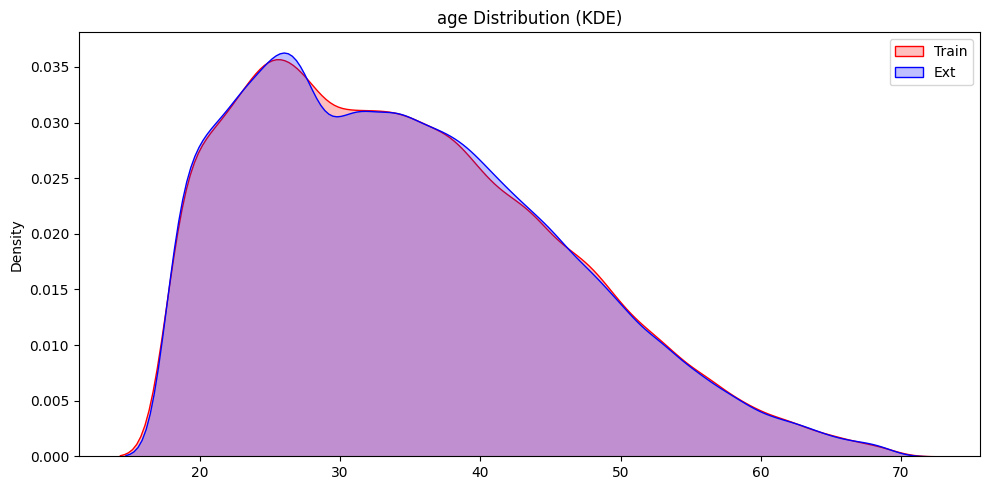

KS Statistic: 0.008517100051702475
P-Value: 0.012536215679016933
Same distribution?: False


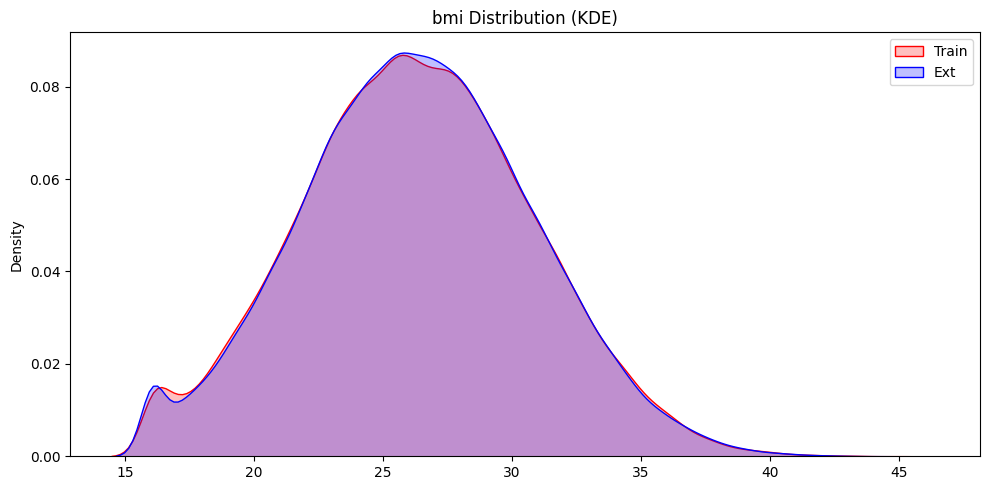

KS Statistic: 0.0081931429999621
P-Value: 0.01661895561155022
Same distribution?: False


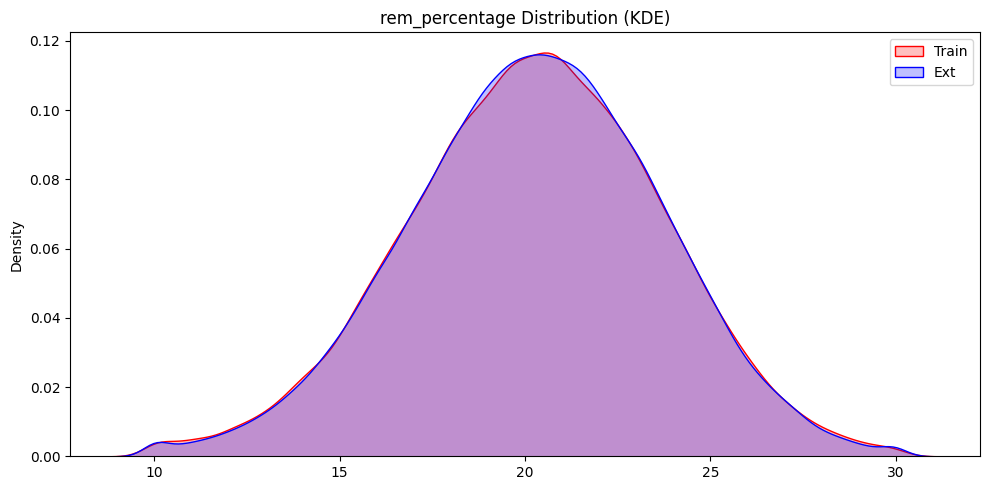

KS Statistic: 0.008104747719992644
P-Value: 0.018417389061339086
Same distribution?: False


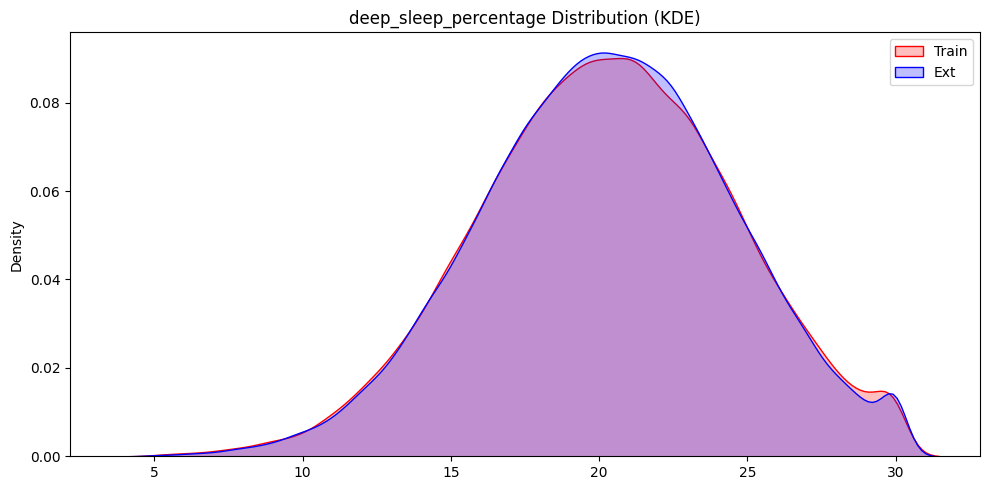

KS Statistic: 0.013737095624775875
P-Value: 2.8517338678816138e-06
Same distribution?: False


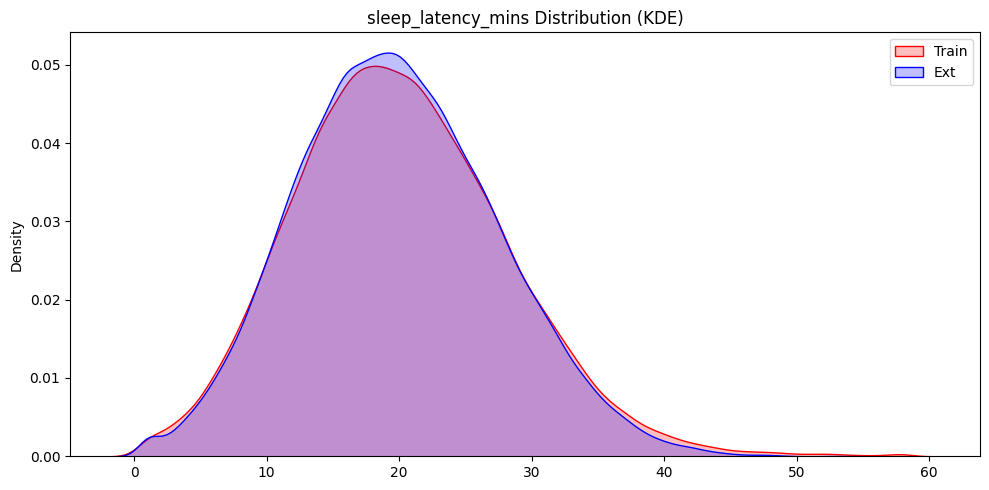

KS Statistic: 0.028499131790108163
P-Value: 1.3979754174343405e-25
Same distribution?: False


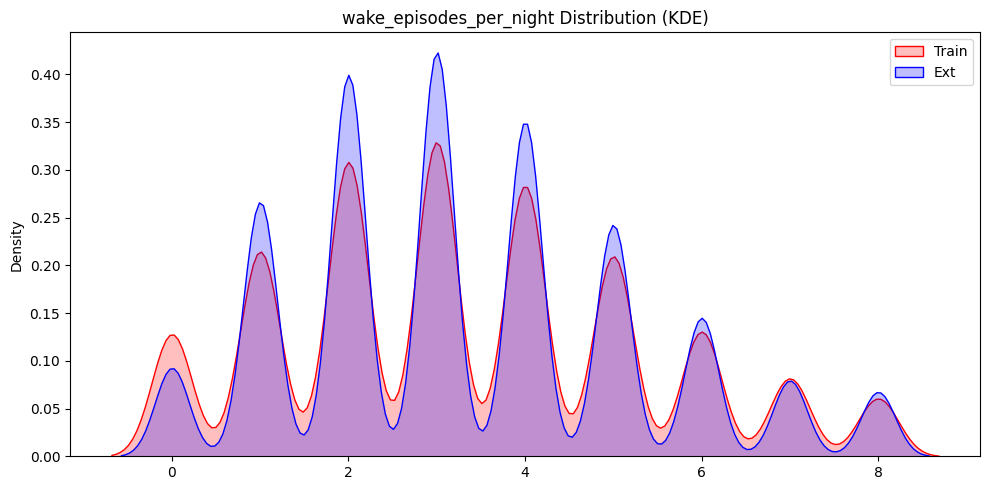

KS Statistic: 0.2995396323678791
P-Value: 0.0
Same distribution?: False


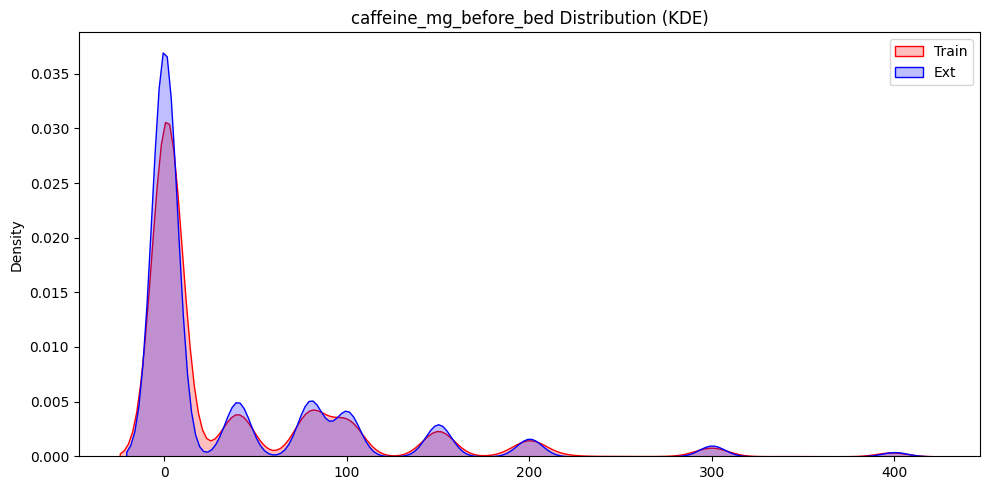

KS Statistic: 0.020464680288903025
P-Value: 2.1344905095310894e-13
Same distribution?: False


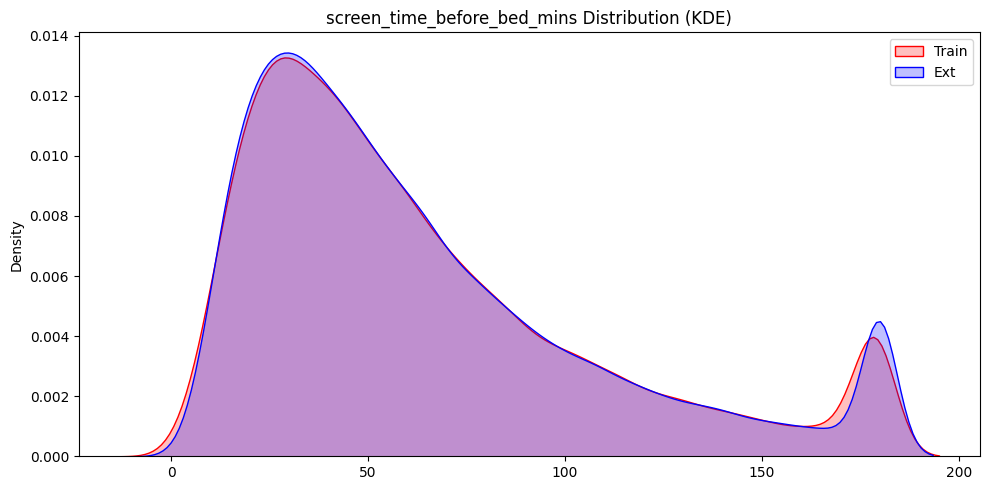

KS Statistic: 0.01061395992608375
P-Value: 0.0006463237396160462
Same distribution?: False


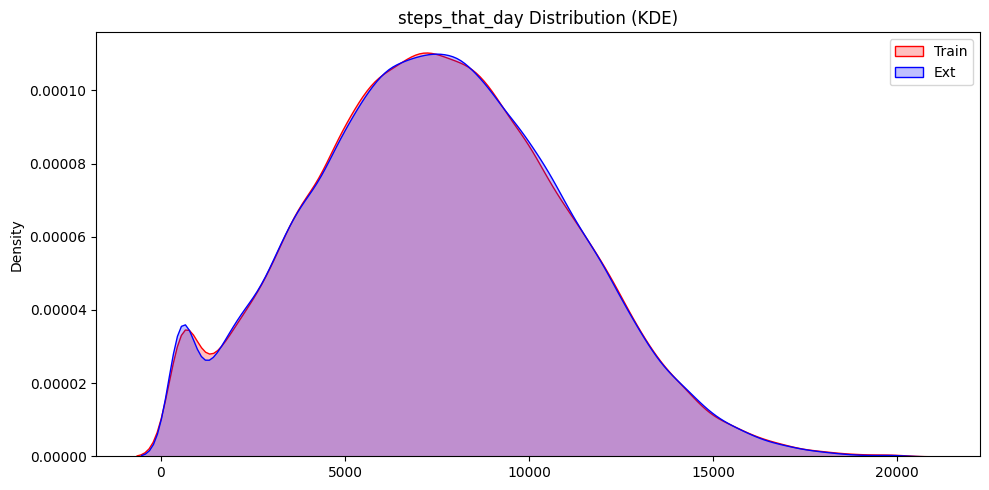

KS Statistic: 0.24863674141845743
P-Value: 0.0
Same distribution?: False


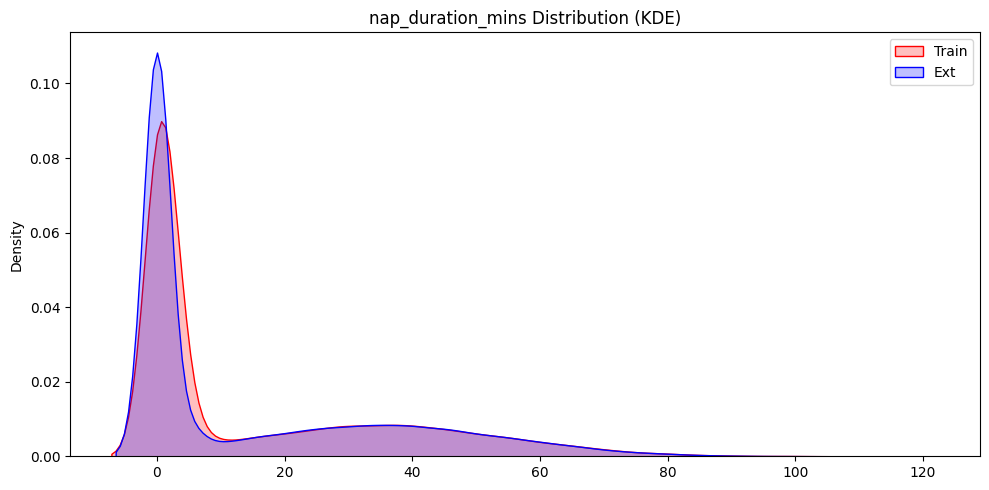

KS Statistic: 0.016321602075142883
P-Value: 1.6288910011098043e-08
Same distribution?: False


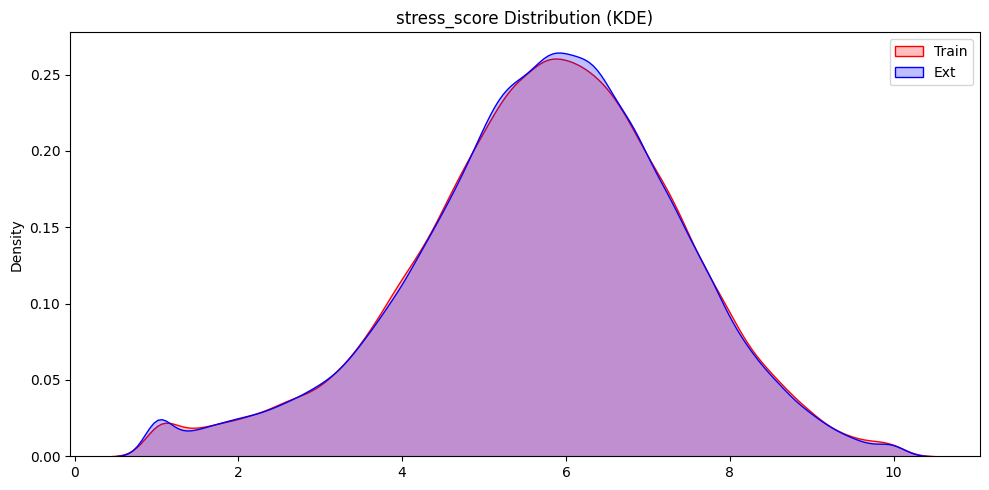

KS Statistic: 0.016523468627856752
P-Value: 6.980452673919679e-09
Same distribution?: False


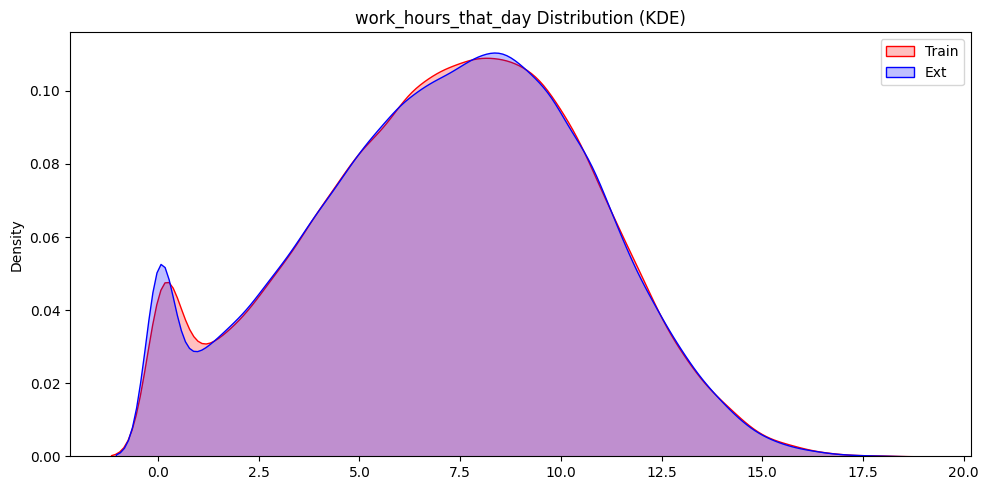

KS Statistic: 0.0073428551025820354
P-Value: 0.042637514343700444
Same distribution?: False


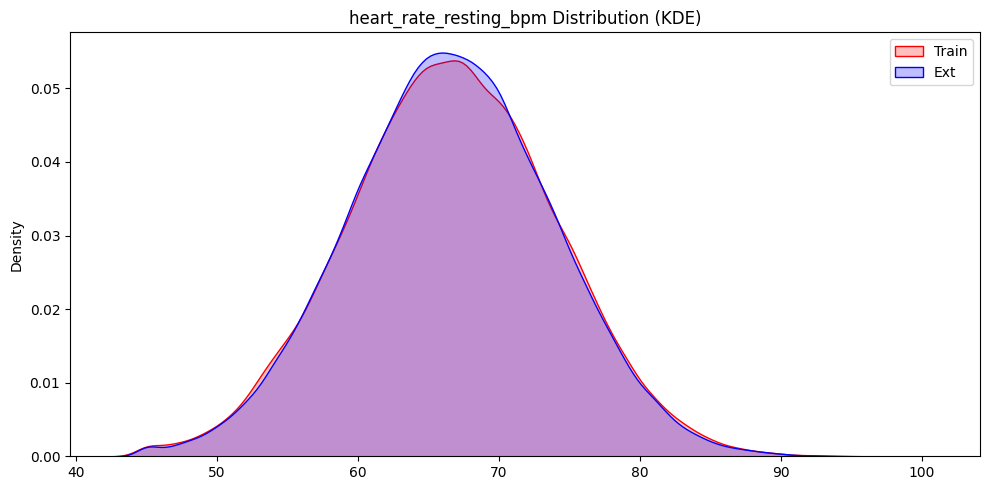

KS Statistic: 0.015049512009933222
P-Value: 1.927928168033185e-07
Same distribution?: False


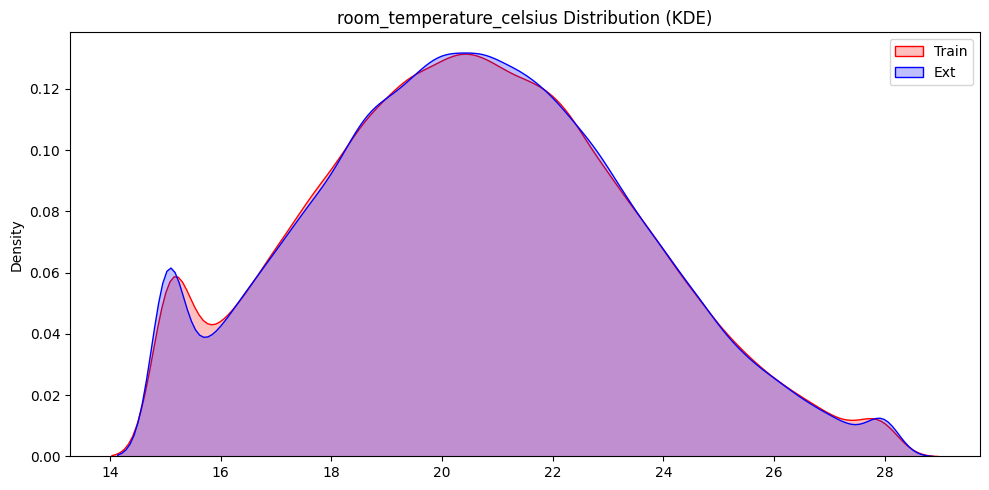

KS Statistic: 0.005267582434397872
P-Value: 0.27504371320961996
Same distribution?: True


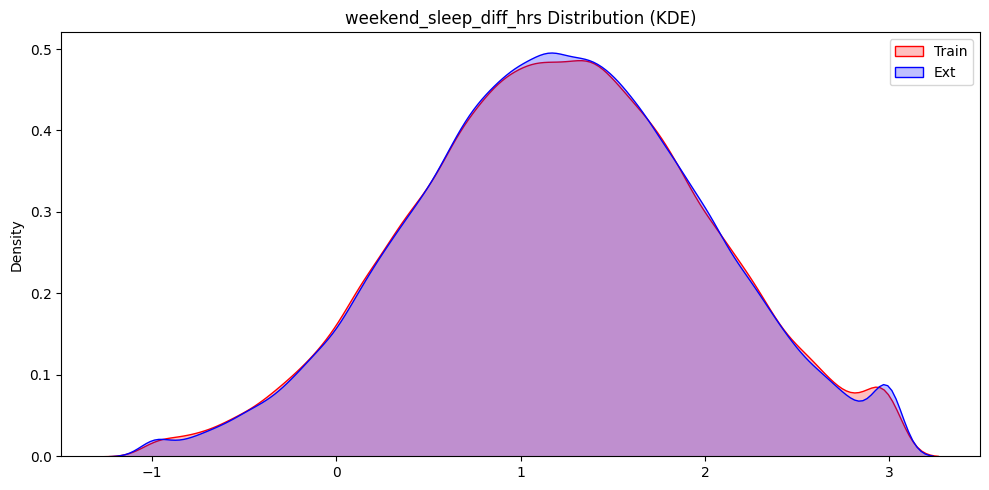

KS Statistic: 0.00984314037675138
P-Value: 0.0019899306428445415
Same distribution?: False


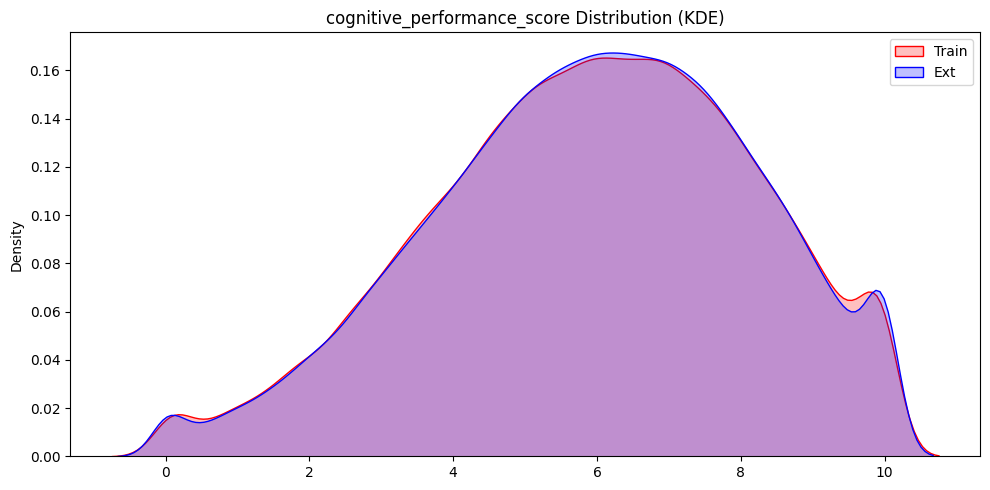

In [61]:
num_cols = train.select_dtypes(include='number').columns.tolist()

if 'person_id' in num_cols:
    num_cols.remove('person_id')

for col in num_cols:

    t_vals = train[col].dropna().values
    ext_vals = ext[col].dropna().values

    # KS TEST
    stat, p_val = stats.ks_2samp(t_vals, ext_vals)

    print(f'KS Statistic: {stat}')
    print(f'P-Value: {p_val}')
    print(f'Same distribution?: {p_val > 0.05}')

    #KDE Plot
    plt.figure(figsize=(10,5))

    sns.kdeplot(
        t_vals,
        label='Train',
        color='red',
        fill=True
    )

    sns.kdeplot(
        ext_vals,
        label='Ext',
        color='blue',
        fill=True
    )

    plt.title(f'{col} Distribution (KDE)')
    plt.legend()

    plt.tight_layout()
    plt.show()

Before we combining these two dataset to make Adversarial Validation I want to make train data columns alike to the external dataaset there are datatype differences between these dataset even there is no differences as datatype some data in training set is like 31.470103 and the external set same column contains values like 25.7 so we need to fix this. If we dont Adversarial Validation score ROC AUC goes up like <80-90%

In [62]:
train.dtypes

person_id                        int64
age                              int64
gender                          object
occupation                      object
bmi                            float64
country                         object
rem_percentage                 float64
deep_sleep_percentage          float64
sleep_latency_mins               int64
wake_episodes_per_night          int64
caffeine_mg_before_bed         float64
screen_time_before_bed_mins      int64
steps_that_day                   int64
nap_duration_mins                int64
stress_score                   float64
work_hours_that_day            float64
chronotype                      object
mental_health_condition         object
heart_rate_resting_bpm           int64
room_temperature_celsius       float64
weekend_sleep_diff_hrs         float64
season                          object
day_type                        object
cognitive_performance_score    float64
Source                          object
dtype: object

In [63]:
train["bmi"] = train["bmi"].round(1)

In [64]:
train["weekend_sleep_diff_hrs"] = train["weekend_sleep_diff_hrs"].round(2)

In [65]:
train["room_temperature_celsius"] = train["room_temperature_celsius"].round(1)

In [66]:
train["rem_percentage"] = train["rem_percentage"].round(1)

In [67]:
train["deep_sleep_percentage"] = train["deep_sleep_percentage"].round(1)

In [68]:
train["caffeine_mg_before_bed"] = train["caffeine_mg_before_bed"].round().astype("Int64")

In [69]:
train["stress_score"] = train["stress_score"].round(1)

In [70]:
train["work_hours_that_day"] = train["work_hours_that_day"].round(1)

all done now we can merge this datasets

In [71]:
common_cols = [c for c in train.columns if c in ext.columns]
combined = pd.concat([
    train[common_cols],
    ext[common_cols]
], ignore_index=True)

print(combined.shape)
print(combined.isnull().sum())

(154026, 25)
person_id                         0
age                               0
gender                            0
occupation                     1378
bmi                            1752
country                           0
rem_percentage                    0
deep_sleep_percentage             0
sleep_latency_mins                0
wake_episodes_per_night           0
caffeine_mg_before_bed         1463
screen_time_before_bed_mins       0
steps_that_day                    0
nap_duration_mins                 0
stress_score                   1715
work_hours_that_day               0
chronotype                     1968
mental_health_condition        1096
heart_rate_resting_bpm            0
room_temperature_celsius          0
weekend_sleep_diff_hrs            0
season                            0
day_type                          0
cognitive_performance_score       0
Source                            0
dtype: int64


In [72]:
combined.head()

,person_id,age,gender,occupation,bmi,country,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,screen_time_before_bed_mins,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,heart_rate_resting_bpm,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,Source
0,1,34,Male,Healthcare personnel,31.5,China,14.4,14.6,27,7,0,97,7184,0,9.9,10.0,Morning,Both,78,19.0,-0.07,Autumn-Winter,Weekday,0.136441,Train
1,2,32,Female,Engineer,31.0,USA,21.8,27.2,20,4,4,180,5057,1,6.6,6.3,Evening,Healthy,76,21.2,0.94,Autumn-Winter,Weekday,5.848312,Train
2,3,39,Male,Homemaker,21.5,Spain,18.2,25.5,33,7,148,23,10816,70,6.1,3.8,Neutral,Depression,66,18.5,1.24,Spring-Summer,Weekend,6.828276,Train
3,4,40,Female,Teacher,23.3,New Zealand,21.4,15.9,21,2,0,180,5238,115,3.2,4.6,Evening,Healthy,60,21.9,0.73,Autumn-Winter,Weekend,8.144649,Train
4,5,36,Female,NaN,NaN,Portugal,25.5,16.4,21,8,100,145,4042,0,7.2,3.2,Neutral,Both,74,19.2,-0.22,Autumn-Winter,Weekday,0.431423,Train


In [73]:
combined=combined.drop(columns=['person_id'])#model learns nothing from person_id column so its a noise I drop it.

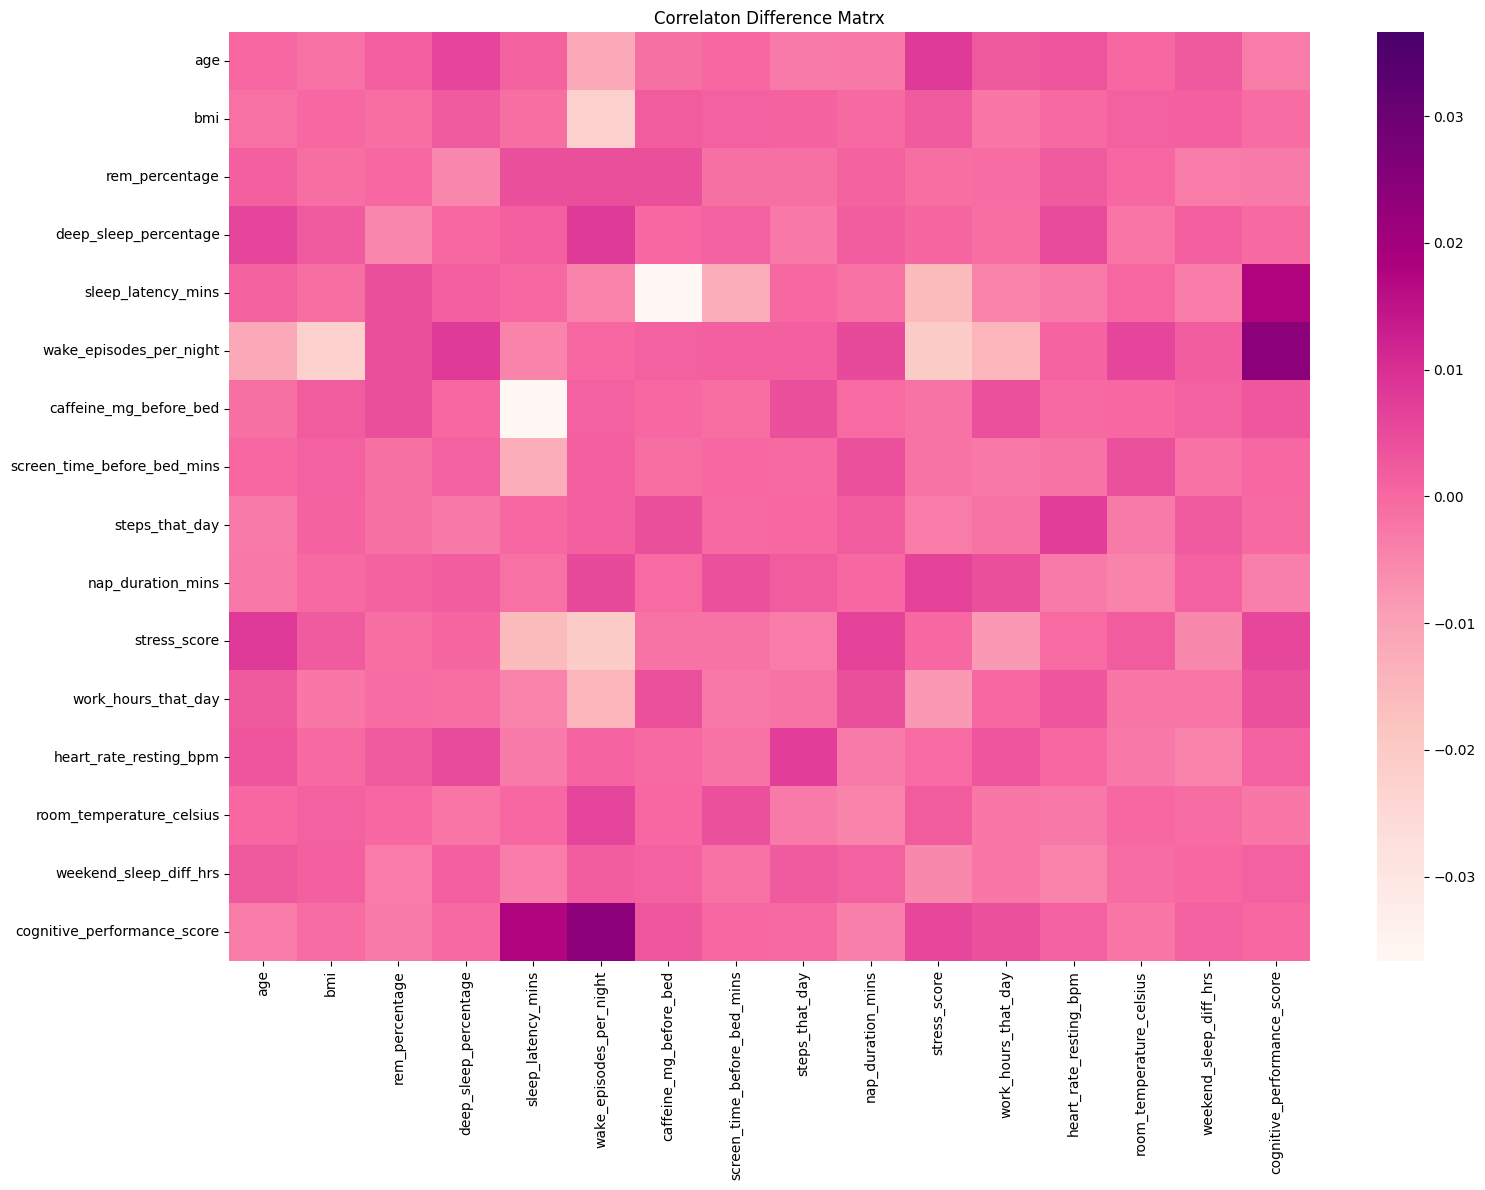

In [74]:
#correlation matrixes
corr_train=train[num_cols].corr()
corr_ext=ext[num_cols].corr()

#correlation difference
corr_diff=corr_train-corr_ext

#absolute value
vlim = float(np.nanmax(np.abs(corr_diff.values)))

#safety
if (not np.isfinite(vlim)) or vlim <= 0:
    vlim = 1e-6

#heatmap
plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_diff,
    cmap='RdPu',
    center=0,
    annot=False,
    vmin=-vlim,
    vmax=vlim
)

plt.title(
    'Correlaton Difference Matrx'
)

plt.tight_layout()
plt.show()

### Categorical Values Handling

In [75]:
print(combined['occupation'].nunique())
print(combined['country'].nunique())
print(combined['chronotype'].nunique())
print(combined['mental_health_condition'].nunique())
print(combined['season'].nunique())
print(combined['day_type'].nunique())
print(combined['Source'].nunique())

11
11
3
4
2
2
2


### First of all I am going to handle binary columns like day_type

In [76]:
#our temporary target column Source must be binary encoded
combined['Source']=combined['Source'].map({'Train': 1, 'External': 0})

In [77]:
combined['day_type']=combined['day_type'].map({'Weekday': 1, 'Weekend': 0})

In [78]:
combined['season']=combined['season'].map({'Autumn-Winter': 1, 'Spring-Summer': 0})

# Missing Value Imputation

### Before taking action on the other columns I want to handle missing values.

In [79]:
combined.isnull().sum()

age                               0
gender                            0
occupation                     1378
bmi                            1752
country                           0
rem_percentage                    0
deep_sleep_percentage             0
sleep_latency_mins                0
wake_episodes_per_night           0
caffeine_mg_before_bed         1463
screen_time_before_bed_mins       0
steps_that_day                    0
nap_duration_mins                 0
stress_score                   1715
work_hours_that_day               0
chronotype                     1968
mental_health_condition        1096
heart_rate_resting_bpm            0
room_temperature_celsius          0
weekend_sleep_diff_hrs            0
season                            0
day_type                          0
cognitive_performance_score       0
Source                            0
dtype: int64

### My aim is to train model to fill these missing values column by column.

In [80]:
print(combined['mental_health_condition'].value_counts())#Checking class imbalance

mental_health_condition
Healthy       106970
Anxiety        23117
Depression     15148
Both            7695
Name: count, dtype: int64


Based on the little gap between classes I am going to use class_weight='balanced' parameter when I train the model.

In [81]:
mental_features = [
    'age',
    'gender',
    'rem_percentage',
    'deep_sleep_percentage',
    'sleep_latency_mins',
    'wake_episodes_per_night',
    'caffeine_mg_before_bed',
    'screen_time_before_bed_mins',
    'steps_that_day',
    'nap_duration_mins',
    'stress_score',
    'work_hours_that_day',
    'heart_rate_resting_bpm',
    'weekend_sleep_diff_hrs',
    'day_type'
]

In [82]:
#known ones and the unknown ones seperating for to train model using which to which.
mental_known=combined[combined['mental_health_condition'].notnull()].copy()
mental_unknown=combined[combined['mental_health_condition'].isnull()].copy()

In [83]:
mental_fill_values={}
#Temporary way I am filling them with median
for col in mental_features:
    if combined[col].dtype in ['int64', 'float64']:
        median_val = mental_known[col].median()
        mental_fill_values[col] = median_val
        mental_known[col] = mental_known[col].fillna(median_val)
        mental_unknown[col] = mental_unknown[col].fillna(median_val)
    else:
        mode_val = mental_known[col].mode()[0]
        mental_fill_values[col] = mode_val
        mental_known[col] = mental_known[col].fillna(mode_val)
        mental_unknown[col] = mental_unknown[col].fillna(mode_val)

In [84]:
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMClassifier

In [85]:
mental_encoders = {}

for col in mental_known.select_dtypes(include='object').columns:
    if col == 'mental_health_condition':  # ← ekle
      continue


    le=LabelEncoder()

    all_vals=pd.concat([mental_known[col], mental_unknown[col]]).astype(str)

    le.fit(all_vals)

    mental_known[col]=le.transform(mental_known[col].astype(str))
    mental_unknown[col]=le.transform(mental_unknown[col].astype(str))

    mental_encoders[col]=le

In [86]:
#target encode
target_le_mental=LabelEncoder()


In [87]:
mental_known['mental_health_condition']=target_le_mental.fit_transform(mental_known['mental_health_condition'])
# train model
model_mental = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42
)

model_mental.fit(
    mental_known[mental_features],
    mental_known['mental_health_condition']
)

#predict missing
preds = model_mental.predict(mental_unknown[mental_features])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014010 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1868
[LightGBM] [Info] Number of data points in the train set: 152930, number of used features: 15
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


In [88]:
#inverse transform
preds_labels = target_le_mental.inverse_transform(preds)

#fill original dataframe
combined.loc[
    combined['mental_health_condition'].isnull(),
    'mental_health_condition'
] = preds_labels

In [89]:
combined['mental_health_condition'].isnull().sum()#Fixed

np.int64(0)

In [90]:
pd.Series(preds_labels).value_counts(normalize=True)

Healthy       0.417883
Depression    0.272810
Both          0.161496
Anxiety       0.147810
Name: proportion, dtype: float64

In the column 'mental_health_condition' we handled successfully. well do the same steps for the other columns as well.

In [91]:
combined['occupation'].value_counts()

occupation
Healthcare personnel    27426
Student                 22688
Engineer                18334
Manager                 12399
Teacher                 12289
Sales                   10772
Freelancer              10695
Retired                 10687
Driver                  10667
Homemaker                9025
Lawyer                   7666
Name: count, dtype: int64

In [92]:
occupation_features = [
    'age',
    'gender',
    'bmi',
    'stress_score',
    'mental_health_condition',
    'rem_percentage',
    'deep_sleep_percentage',
    'sleep_latency_mins',
    'wake_episodes_per_night',
    'nap_duration_mins',
    'weekend_sleep_diff_hrs',
    'work_hours_that_day',
    'day_type',
    'chronotype'
]

In [93]:
known_occupation=combined[combined['occupation'].notnull()].copy()
unknown_occupation=combined[combined['occupation'].isnull()].copy()

In [94]:
occupation_fill_values={}

In [95]:
for col in occupation_features:
    if combined[col].dtype in ['int64', 'float64']:
        median_val=known_occupation[col].median()
        occupation_fill_values[col]=median_val
        known_occupation[col]=known_occupation[col].fillna(median_val)
        unknown_occupation[col]=unknown_occupation[col].fillna(median_val)
    else:
        mode_val = known_occupation[col].mode()[0]
        occupation_fill_values[col]=mode_val
        known_occupation[col]=known_occupation[col].fillna(mode_val)
        unknown_occupation[col]=unknown_occupation[col].fillna(mode_val)

In [96]:
from sklearn.preprocessing import LabelEncoder
occupation_encoders = {}
for col in known_occupation.select_dtypes(include='object').columns:
    if col == 'occupation':  
      continue
    le = LabelEncoder()
    all_vals = pd.concat([known_occupation[col], unknown_occupation[col]]).astype(str)
    le.fit(all_vals)

    known_occupation[col] = le.transform(known_occupation[col].astype(str))
    unknown_occupation[col] = le.transform(unknown_occupation[col].astype(str))

    occupation_encoders[col] = le

In [97]:
target_le_occupation=LabelEncoder()
known_occupation['occupation']=target_le_occupation.fit_transform(known_occupation['occupation'])

In [98]:
model_occupation = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    class_weight='balanced'
)

model_occupation.fit(
    known_occupation[occupation_features],
    known_occupation['occupation']
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003032 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1475
[LightGBM] [Info] Number of data points in the train set: 152648, number of used features: 14
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895


LGBMClassifier(class_weight='balanced', learning_rate=0.05, n_estimators=300,
               random_state=42)

In [99]:
preds_occupation=model_occupation.predict(unknown_occupation[occupation_features])

preds_occupation_labels = target_le_occupation.inverse_transform(preds_occupation)

combined.loc[
    combined['occupation'].isnull(),
    'occupation'
] = preds_occupation_labels

In [100]:
combined['occupation'].isnull().sum()


np.int64(0)

In [101]:
combined['occupation'].value_counts(normalize=True)

occupation
Healthcare personnel    0.179223
Student                 0.148462
Engineer                0.119993
Manager                 0.081162
Teacher                 0.080525
Sales                   0.070319
Freelancer              0.070176
Retired                 0.070099
Driver                  0.069878
Homemaker               0.059542
Lawyer                  0.050621
Name: proportion, dtype: float64

In [102]:
print(combined['chronotype'].value_counts())#Checking class imbalance

chronotype
Neutral    69095
Evening    45008
Morning    37955
Name: count, dtype: int64


In [103]:
chronotype_features = [
    'age',
    'gender',
    'bmi',
    'stress_score',
    'mental_health_condition',
    'rem_percentage',
    'deep_sleep_percentage',
    'sleep_latency_mins',
    'wake_episodes_per_night',
    'nap_duration_mins',
    'weekend_sleep_diff_hrs',
    'work_hours_that_day',
    'day_type',
    'occupation'
]

In [104]:
known_chronotype=combined[combined['chronotype'].notnull()].copy()
unknown_chronotype=combined[combined['chronotype'].isnull()].copy()

In [105]:
chronotype_fill_values={}

In [106]:
for col in chronotype_features:
    if combined[col].dtype in ['int64', 'float64']:
        median_val=known_chronotype[col].median()
        chronotype_fill_values[col]=median_val
        known_chronotype[col]=known_chronotype[col].fillna(median_val)
        unknown_chronotype[col]=unknown_chronotype[col].fillna(median_val)
    else:
        mode_val = known_chronotype[col].mode()[0]
        chronotype_fill_values[col]=mode_val
        known_chronotype[col]=known_chronotype[col].fillna(mode_val)
        unknown_chronotype[col]=unknown_chronotype[col].fillna(mode_val)

In [107]:
from sklearn.preprocessing import LabelEncoder
chronotype_encoders = {}
for col in known_chronotype.select_dtypes(include='object').columns:
    if col == 'chronotype':
      continue
    le = LabelEncoder()
    all_vals = pd.concat([known_chronotype[col], unknown_chronotype[col]]).astype(str)
    le.fit(all_vals)

    known_chronotype[col] = le.transform(known_chronotype[col].astype(str))
    unknown_chronotype[col] = le.transform(unknown_chronotype[col].astype(str))

    chronotype_encoders[col] = le

In [108]:
target_le_chronotype=LabelEncoder()
known_chronotype['chronotype']=target_le_chronotype.fit_transform(known_chronotype['chronotype'])

In [109]:
model_chronotype = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    class_weight='balanced'
)

model_chronotype.fit(
    known_chronotype[chronotype_features],
    known_chronotype['chronotype']
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003101 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1483
[LightGBM] [Info] Number of data points in the train set: 152058, number of used features: 14
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


LGBMClassifier(class_weight='balanced', learning_rate=0.05, n_estimators=300,
               random_state=42)

In [110]:
preds_chronotype=model_chronotype.predict(unknown_chronotype[chronotype_features])

preds_chronotype_labels = target_le_chronotype.inverse_transform(preds_chronotype)

combined.loc[
    combined['chronotype'].isnull(),
    'chronotype'
] = preds_chronotype_labels

In [111]:
combined['chronotype'].isnull().sum()

np.int64(0)

In [112]:
combined['chronotype'].value_counts(normalize=True)

chronotype
Neutral    0.452125
Evening    0.297210
Morning    0.250665
Name: proportion, dtype: float64

### Okey now I filled all the object columns one by one training models now its time to fill the rest numeric columns.

In [113]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
numeric_cols = [
    'bmi',
    'caffeine_mg_before_bed',
    'stress_score',
    'rem_percentage',
    'deep_sleep_percentage',
    'sleep_latency_mins',
    'wake_episodes_per_night',
    'steps_that_day',
    'nap_duration_mins',
    'work_hours_that_day',
    'heart_rate_resting_bpm',
    'room_temperature_celsius',
    'weekend_sleep_diff_hrs'
]

In [114]:
df_num=combined[numeric_cols].copy()

In [115]:
imputer = IterativeImputer(
    random_state=42,
    max_iter=10,
    initial_strategy='median'
)

In [116]:
df_imputed = pd.DataFrame(
    imputer.fit_transform(df_num),
    columns=numeric_cols
)

#write it on to original data combined
combined[numeric_cols] = df_imputed

In [117]:
print(combined[numeric_cols].isnull().sum())

bmi                         0
caffeine_mg_before_bed      0
stress_score                0
rem_percentage              0
deep_sleep_percentage       0
sleep_latency_mins          0
wake_episodes_per_night     0
steps_that_day              0
nap_duration_mins           0
work_hours_that_day         0
heart_rate_resting_bpm      0
room_temperature_celsius    0
weekend_sleep_diff_hrs      0
dtype: int64


In [118]:
print(combined.isnull().sum())

age                            0
gender                         0
occupation                     0
bmi                            0
country                        0
rem_percentage                 0
deep_sleep_percentage          0
sleep_latency_mins             0
wake_episodes_per_night        0
caffeine_mg_before_bed         0
screen_time_before_bed_mins    0
steps_that_day                 0
nap_duration_mins              0
stress_score                   0
work_hours_that_day            0
chronotype                     0
mental_health_condition        0
heart_rate_resting_bpm         0
room_temperature_celsius       0
weekend_sleep_diff_hrs         0
season                         0
day_type                       0
cognitive_performance_score    0
Source                         0
dtype: int64


# Summary of the Missing Value Imputation
- 'mental_health_condition' -> LGBMClassifier
- 'occupation' -> LGBMClassifier  
- 'chronotype' -> LGBMClassifier
- Numeric columns -> IterativeImputer

In [119]:
combined.head()

,age,gender,occupation,bmi,country,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,screen_time_before_bed_mins,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,heart_rate_resting_bpm,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,Source
0,34,Male,Healthcare personnel,31.500000,China,14.4,14.6,27.0,7.0,0.0,97,7184.0,0.0,9.9,10.0,Morning,Both,78.0,19.0,-0.07,1,1,0.136441,1
1,32,Female,Engineer,31.000000,USA,21.8,27.2,20.0,4.0,4.0,180,5057.0,1.0,6.6,6.3,Evening,Healthy,76.0,21.2,0.94,1,1,5.848312,1
2,39,Male,Homemaker,21.500000,Spain,18.2,25.5,33.0,7.0,148.0,23,10816.0,70.0,6.1,3.8,Neutral,Depression,66.0,18.5,1.24,0,0,6.828276,1
3,40,Female,Teacher,23.300000,New Zealand,21.4,15.9,21.0,2.0,0.0,180,5238.0,115.0,3.2,4.6,Evening,Healthy,60.0,21.9,0.73,1,0,8.144649,1
4,36,Female,Student,28.747109,Portugal,25.5,16.4,21.0,8.0,100.0,145,4042.0,0.0,7.2,3.2,Neutral,Both,74.0,19.2,-0.22,1,1,0.431423,1


In [120]:
combined.tail()

,age,gender,occupation,bmi,country,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,screen_time_before_bed_mins,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,heart_rate_resting_bpm,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,Source
154021,44,Female,Healthcare personnel,25.9,USA,26.8,24.6,18.0,0.0,0.0,149,10706.0,19.0,5.4,7.7,Morning,Anxiety,72.0,19.1,1.93,0,0,8.94,0
154022,44,Female,Manager,30.2,China,21.6,22.3,9.0,1.0,0.0,66,10568.0,32.0,6.8,9.3,Morning,Healthy,80.0,18.6,1.44,0,1,4.05,0
154023,39,Male,Manager,29.2,Argentina,21.4,14.3,9.0,2.0,0.0,28,500.0,58.0,6.1,7.7,Neutral,Healthy,74.0,19.4,0.62,0,1,6.48,0
154024,33,Female,Healthcare personnel,27.3,China,21.9,23.6,23.0,3.0,150.0,12,2748.0,0.0,6.7,7.5,Neutral,Anxiety,68.0,20.6,2.32,1,0,4.08,0
154025,30,Male,Sales,24.3,USA,14.5,25.3,27.0,3.0,0.0,42,5049.0,16.0,6.2,10.3,Evening,Depression,48.0,21.1,-0.12,1,1,5.43,0


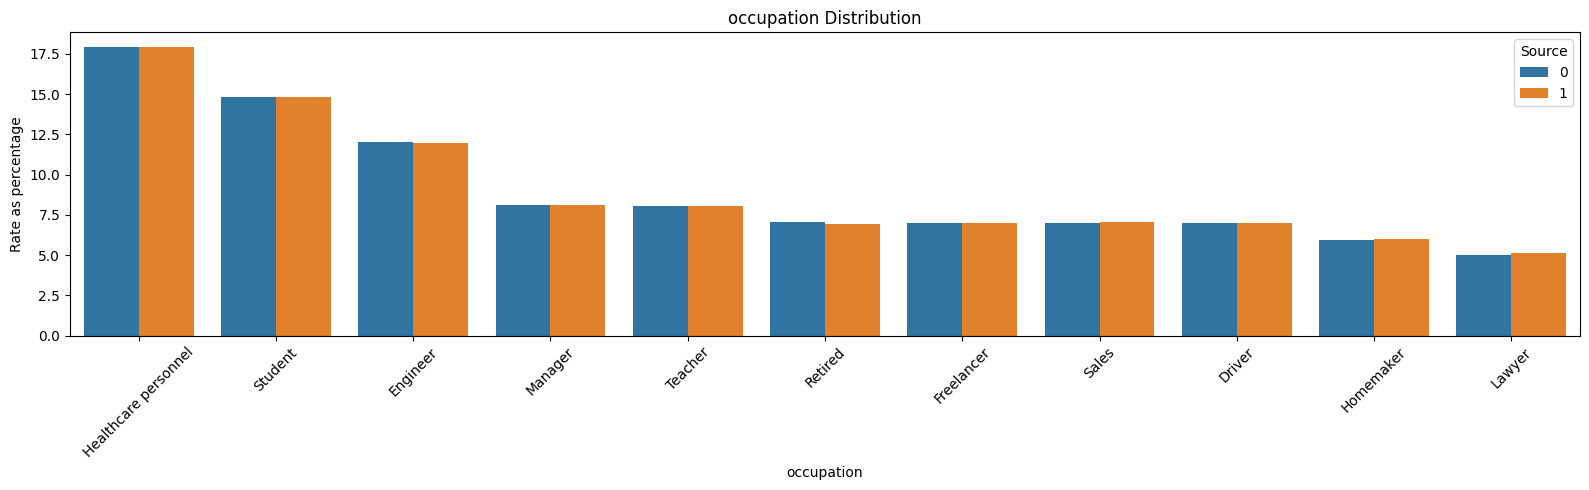

In [121]:
plt.figure(figsize=(16, 5))

prop_df = (
    combined.groupby('Source')['occupation']
    .value_counts(normalize=True)
    .rename('Percentage')
    .reset_index()
)

prop_df['Percentage'] *= 100

sns.barplot(
    data=prop_df,
    x='occupation',
    y='Percentage',
    hue='Source'
)

plt.title('occupation Distribution')
plt.xticks(rotation=45)
plt.ylabel('Rate as percentage')
plt.tight_layout()

plt.show()

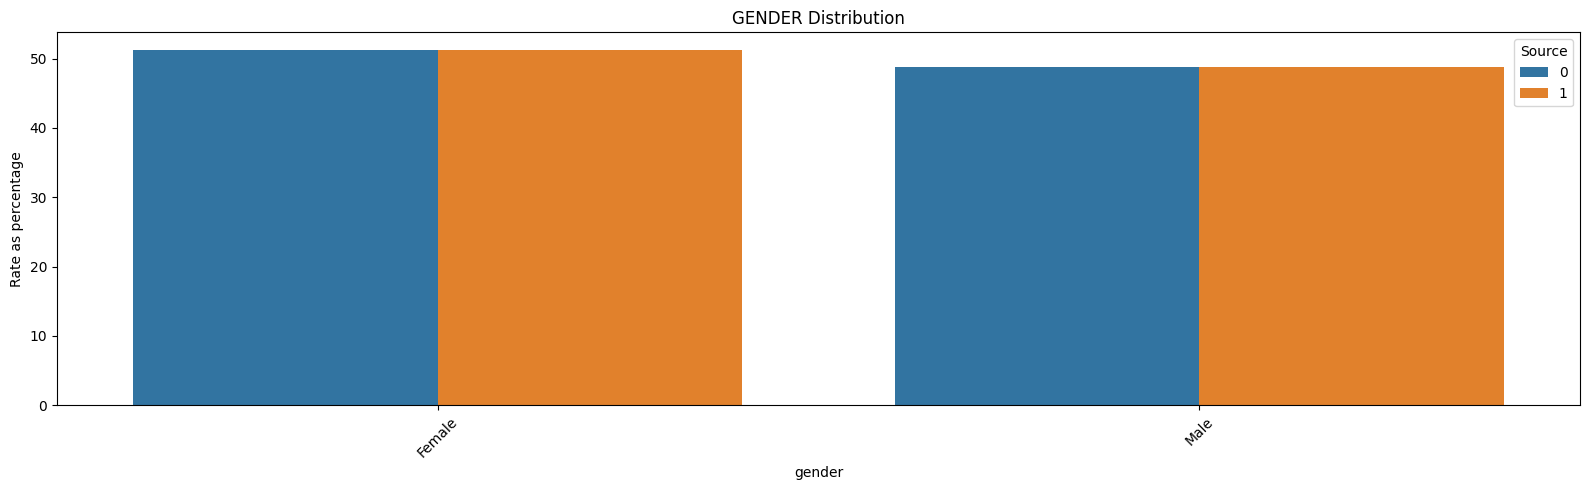

In [122]:
plt.figure(figsize=(16, 5))

prop_df = (
    combined.groupby('Source')['gender']
    .value_counts(normalize=True)
    .rename('Percentage')
    .reset_index()
)

prop_df['Percentage'] *= 100

sns.barplot(
    data=prop_df,
    x='gender',
    y='Percentage',
    hue='Source'
)

plt.title('GENDER Distribution')
plt.xticks(rotation=45)
plt.ylabel('Rate as percentage')
plt.tight_layout()

plt.show()

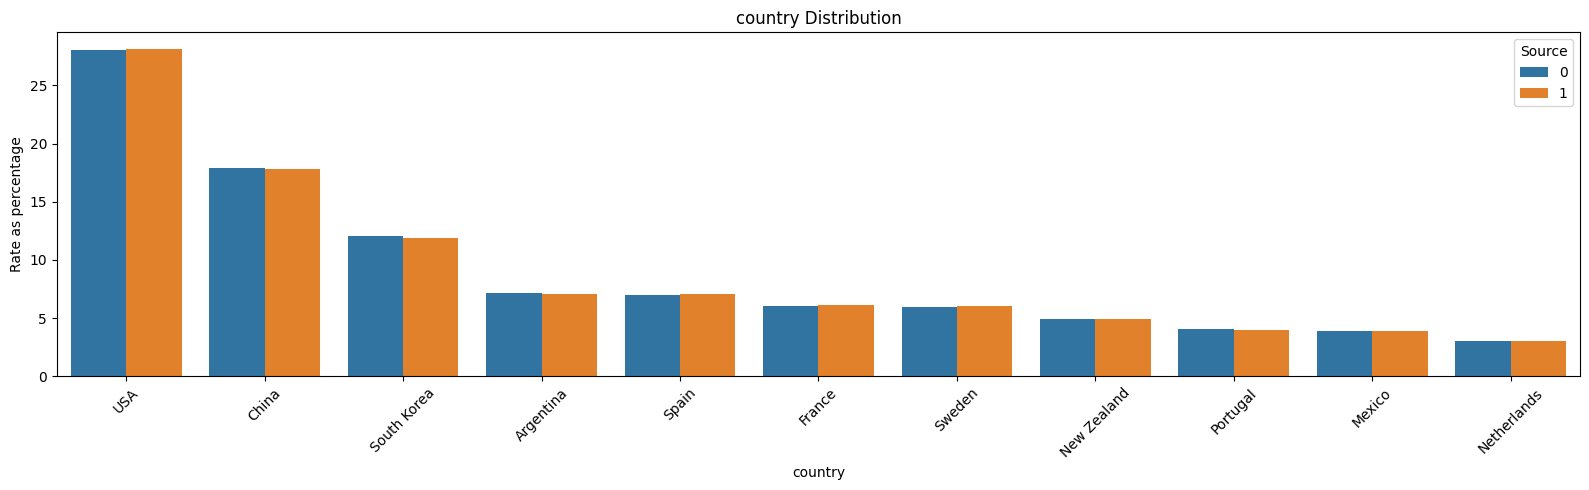

In [123]:
plt.figure(figsize=(16, 5))

prop_df = (
    combined.groupby('Source')['country']
    .value_counts(normalize=True)
    .rename('Percentage')
    .reset_index()
)

prop_df['Percentage'] *= 100

sns.barplot(
    data=prop_df,
    x='country',
    y='Percentage',
    hue='Source'
)

plt.title('country Distribution')
plt.xticks(rotation=45)
plt.ylabel('Rate as percentage')
plt.tight_layout()

plt.show()

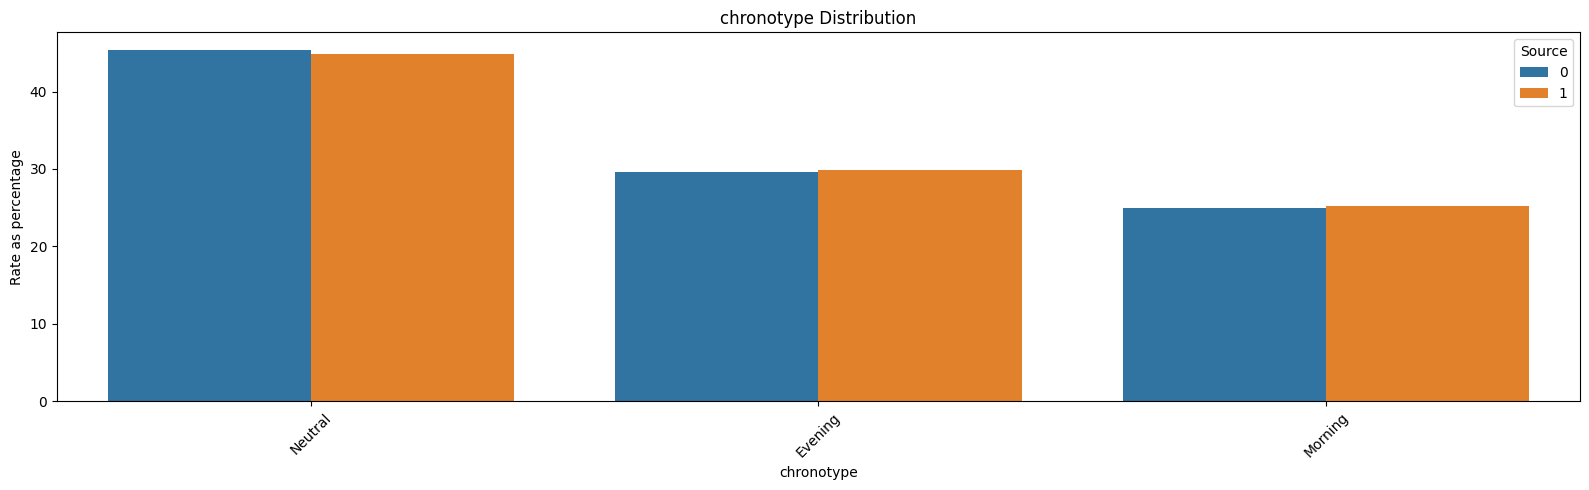

In [124]:
plt.figure(figsize=(16, 5))

prop_df = (
    combined.groupby('Source')['chronotype']
    .value_counts(normalize=True)
    .rename('Percentage')
    .reset_index()
)

prop_df['Percentage'] *= 100

sns.barplot(
    data=prop_df,
    x='chronotype',
    y='Percentage',
    hue='Source'
)

plt.title('chronotype Distribution')
plt.xticks(rotation=45)
plt.ylabel('Rate as percentage')
plt.tight_layout()

plt.show()

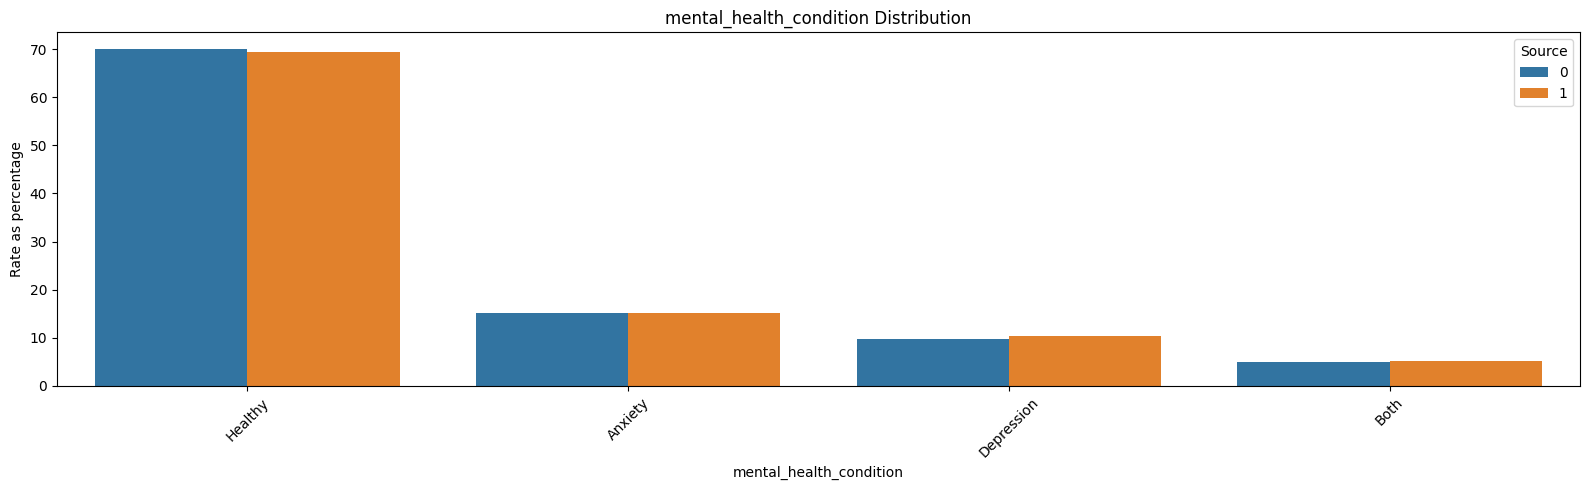

In [125]:
plt.figure(figsize=(16, 5))

prop_df = (
    combined.groupby('Source')['mental_health_condition']
    .value_counts(normalize=True)
    .rename('Percentage')
    .reset_index()
)

prop_df['Percentage'] *= 100

sns.barplot(
    data=prop_df,
    x='mental_health_condition',
    y='Percentage',
    hue='Source'
)

plt.title('mental_health_condition Distribution')
plt.xticks(rotation=45)
plt.ylabel('Rate as percentage')
plt.tight_layout()

plt.show()

In [126]:
print(combined['occupation'].nunique())
print(combined['country'].nunique())
print(combined['chronotype'].nunique())
print(combined['mental_health_condition'].nunique())

11
11
3
4


# Feature Engineering
## As a binary column only gender column left so I am going to make binary encoding on to gender column and use one hot encoding for the chronotype and mental_heath_condition columns.

In [127]:
combined['gender'] = combined['gender'].map({'Female': 1, 'Male': 0})

In [128]:
combined = pd.get_dummies(combined,
    columns=['chronotype', 'mental_health_condition'],
    drop_first=False
)

### For the rest I am going to use a different interesting methodology that I am thinking going to perform better. I will sent the data into claude and ask it to make 80 word explanation for the each variable of left columns in dataset and encode them using pca

In [129]:
print(combined['occupation'].unique())

['Healthcare personnel' 'Engineer' 'Homemaker' 'Teacher' 'Student' 'Sales'
 'Manager' 'Lawyer' 'Retired' 'Driver' 'Freelancer']


In [130]:
occupations_dict = {
    'Healthcare personnel': 'Healthcare personnel are highly dedicated professionals who provide essential medical services, including diagnosis, treatment, and preventive care, to individuals across diverse communities. This broad category encompasses doctors, nurses, technicians, and support staff working in hospitals, clinics, and emergency settings. They handle complex health challenges, administer medications, perform critical surgical procedures, and ensure overall patient safety. By maintaining strict ethical standards and demonstrating profound empathy, these vital workers continuously improve public health outcomes and actively save countless lives every single day.',

    'Engineer': 'Engineers are analytical professionals who apply scientific principles, mathematical logic, and advanced technological tools to solve complex physical problems. They operate across diverse fields like civil, mechanical, electrical, aerospace, and software development. Their core responsibilities involve designing, constructing, testing, and optimizing innovative structures, machines, or systems. By carefully balancing safety constraints, economic costs, and environmental sustainability, engineers transform theoretical concepts into practical realities. Their continuous pursuit of efficiency and technological advancement drives modern infrastructure development and fuels global industrial progress.',

    'Homemaker': 'Homemakers are dedicated individuals who manage the daily operations of a household without receiving direct financial compensation. They undertake a vast array of essential tasks, including meal preparation, cleaning, grocery shopping, budget management, and providing care for children or elderly relatives. This demanding role requires excellent organizational skills, emotional intelligence, and immense patience. By creating a stable, nurturing, and secure environment, homemakers support the physical and mental health of their families, functioning as the vital invisible foundation of modern society.',

    'Teacher': 'Teachers are influential education professionals dedicated to shaping the intellectual and emotional growth of their students. They design comprehensive lesson plans, facilitate interactive classroom discussions, evaluate academic progress, and provide constructive feedback. Operating across various academic levels, they adapt their instructional methods to meet diverse learning needs. Beyond simply transmitting factual knowledge, teachers inspire critical thinking, instill core ethical values, and foster essential social skills. Their profound dedication ultimately builds a knowledgeable, responsible, and progressive generation prepared for future challenges.',

    'Student': 'Students are individuals actively engaged in the process of learning within formal or informal educational institutions. Their primary focus is acquiring new knowledge, developing practical skills, and achieving specific academic goals. They attend lectures, conduct independent research, collaborate on group projects, and complete rigorous examinations. This developmental phase is absolutely crucial for personal growth and intellectual expansion. By constantly absorbing information and refining their analytical abilities, students prepare themselves to enter the professional workforce and contribute meaningfully to global society.',

    'Sales': 'Sales professionals are dynamic communicators responsible for driving company revenue by connecting valuable products or services with potential customers. They meticulously analyze market trends, identify client needs, deliver persuasive presentations, and expertly negotiate final contracts. Building lasting relationships and ensuring complete customer satisfaction are central to their ongoing success. Operating in retail, corporate, or digital environments, these resilient experts act as the fundamental financial engine for businesses, directly enabling corporate growth, sustaining profitability, and ensuring long term commercial market survival.',

    'Manager': 'Managers are strategic leaders tasked with overseeing organizational operations, allocating resources, and guiding personnel to achieve specific corporate objectives. They formulate business plans, analyze performance metrics, resolve internal conflicts, and make critical financial decisions under pressure. Excellent communication and strong leadership skills allow them to motivate diverse teams, optimize daily workflows, and drive continuous institutional innovation. By seamlessly bridging the gap between executive vision and frontline execution, managers ensure overall operational efficiency, foster talent development, and guarantee lasting business success.',

    'Lawyer': 'Lawyers are highly trained legal professionals who advise and represent individuals, businesses, or government entities in complex judicial matters. They specialize in various fields such as criminal, corporate, family, or intellectual property law. Their duties include drafting formal contracts, conducting extensive legal research, negotiating settlements, and aggressively advocating for clients inside courtrooms. Armed with exceptional analytical abilities and profound knowledge of statutory regulations, lawyers safeguard fundamental human rights, resolve intricate disputes, and uphold the absolute integrity of the justice system.',

    'Retired': 'Retired individuals are older adults who have permanently concluded their active professional careers after reaching a specific age or fulfilling extended service requirements. They transition from traditional employment into a distinct phase sustained by accumulated pensions, personal savings, or state benefits. Free from daily workplace obligations, retirees often channel their abundant time into rewarding hobbies, voluntary community service, extended travel, and meaningful family connections. This well earned period represents a peaceful culmination of decades of rigorous physical and mental labor.',

    'Driver': 'Drivers are essential transportation professionals responsible for safely navigating motorized vehicles to deliver passengers, commercial goods, or critical materials to designated locations. Whether operating heavy commercial trucks, public transit buses, or private taxis, they must strictly adhere to complex traffic regulations. Their responsibilities include conducting routine vehicle inspections, optimizing travel routes, and ensuring absolute passenger safety. Possessing excellent spatial awareness and rapid reflexes, drivers function as the indispensable moving force behind global supply chains, daily public commuting, and international logistics.',

    'Freelancer': 'Freelancers are independent professionals who offer specialized services directly to multiple clients without committing to a single traditional employer. Working across diverse industries like software development, graphic design, and consulting, they operate on a flexible project basis. They enjoy total autonomy over their daily schedules, allowing for an optimized work and personal life balance. However, this independence demands exceptional personal discipline, constant client networking, and rigorous financial management to overcome income volatility and sustain a highly successful independent entrepreneurial career.'
}

In [131]:
#Apply the mapping
combined['occupation'] = combined['occupation'].map(occupations_dict)

In [132]:
# 2. Embedding
from sentence_transformers import SentenceTransformer
import numpy as np

sentence_model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [133]:
unique_texts = combined['occupation'].unique().tolist()
emb_map = dict(zip(unique_texts, sentence_model.encode(unique_texts)))
occ_matrix = np.vstack(combined['occupation'].map(emb_map).values)

In [134]:
# 3. Scale + PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler_occ = StandardScaler()
occ_scaled = scaler_occ.fit_transform(occ_matrix)

pca_occ = PCA(n_components=0.95, random_state=42)
occ_pca = pca_occ.fit_transform(occ_scaled)

pca_df = pd.DataFrame(occ_pca, columns=[f'occ_pca_{i}' for i in range(occ_pca.shape[1])], index=combined.index)
combined = pd.concat([combined.drop(columns=['occupation']), pca_df], axis=1)

In [135]:
print(combined['country'].unique())

['China' 'USA' 'Spain' 'New Zealand' 'Portugal' 'South Korea' 'France'
 'Netherlands' 'Argentina' 'Sweden' 'Mexico']


In [136]:
countries_dict = {
    'China': 'China is a vast East Asian country known for its rich ancient history, profound cultural heritage, and rapid modern economic development. As the most populous nation globally, it boasts diverse landscapes ranging from expansive deserts to towering mountain ranges. Its booming manufacturing sector and technological advancements have transformed it into a global economic powerhouse. Chinese traditions, including distinct culinary arts, philosophy, and architectural marvels like the Great Wall, continue to deeply influence global culture and international trade dynamics profoundly everywhere.',

    'USA': 'The United States of America is a massive North American nation characterized by its diverse geography, multicultural society, and highly influential global presence. It features a robust capitalist economy driven by constant technological innovation, advanced scientific research, and dominant entertainment industries. From bustling metropolitan cities to expansive national parks, the country offers varied environments. Its democratic political system and strong emphasis on individual liberties have historically shaped international relations, making it a central pillar of modern global geopolitical dynamics today.',

    'Spain': 'Spain is a vibrant European country located on the Iberian Peninsula, celebrated for its passionate culture, historic architecture, and beautiful Mediterranean coastlines. It possesses a rich artistic legacy, having produced world renowned painters and writers throughout centuries. The nation enjoys a diverse climate and geography, ranging from lush northern valleys to arid southern plains. Its economy relies heavily on robust tourism, advanced renewable energy sectors, and agricultural exports, creating a modern society deeply rooted in colorful regional traditions every day.',

    'New Zealand': 'New Zealand is a breathtaking island nation in the southwestern Pacific Ocean, globally renowned for its pristine natural landscapes, indigenous Maori culture, and high quality of life. The country features striking geographical diversity, including active volcanoes, deep fiords, and lush rainforests. It maintains a strong agricultural economy, particularly excelling in dairy and wine exports, alongside a thriving tourism industry. With a progressive democratic government, the nation consistently prioritizes environmental sustainability, social equality, and peaceful international diplomatic relations very successfully today.',

    'Portugal': 'Portugal is a captivating southern European country situated along the Atlantic coast, celebrated for its rich maritime history, stunning architecture, and warm climate. As one of the oldest nations in Europe, it boasts a profound cultural heritage reflected in its distinct music, cuisine, and historic monuments. The modern Portuguese economy is largely driven by tourism, renewable energy, and export manufacturing. It offers a relaxed lifestyle, prioritizing social stability, environmental conservation, and deep connections to its traditional regional roots every day.',

    'South Korea': 'South Korea is a dynamic East Asian nation renowned for its rapid technological advancement, vibrant entertainment industry, and highly competitive educational system. Rising from historical conflicts, it has developed a powerhouse economy focused on electronics, automobile manufacturing, and digital innovation. The country beautifully balances ancient traditions, seen in historic palaces and temples, with futuristic urban environments. Its intense work ethic and global cultural exports, including music and cinema, have secured its position as a major modern global influencer worldwide today.',

    'France': 'France is a highly influential Western European country internationally celebrated for its profound contributions to art, philosophy, gastronomy, and literature. It features diverse landscapes, ranging from beautiful Mediterranean beaches to towering Alpine peaks. The nation possesses a robust mixed economy, excelling in aerospace, luxury goods, and tourism. With its rich historical legacy and iconic architectural landmarks, France remains a global cultural epicenter. Its strong commitment to democratic values heavily influences international politics and modern progressive social policies very consistently today.',

    'UK': 'The United Kingdom is a prominent island nation in northwestern Europe, combining rich historical traditions with modern global influence. Comprising four distinct countries, it boasts a deeply layered cultural heritage, famous for its literature, music, and academic institutions. The nation drives a powerful, service oriented economy, highly specialized in finance, technology, and creative industries. Despite shifting geopolitical landscapes, it maintains significant international diplomatic weight. Its diverse society constantly blends ancient royal traditions with highly dynamic, multicultural contemporary urban environments today.',

    'Netherlands': 'The Netherlands is a densely populated Western European country renowned for its innovative water management, progressive social policies, and flat, picturesque landscapes. Famous for its iconic windmills, vibrant tulip fields, and extensive cycling infrastructure, it maintains a highly efficient and sustainable modern lifestyle. The nation features a powerful, export driven economy, strategically centered around advanced agriculture, international logistics, and technology. Its open minded society deeply values freedom, fostering a highly collaborative and forward thinking environment in modern everyday life today.',

    'Argentina': 'Argentina is a vast South American nation known for its striking geographic diversity, encompassing the towering Andes mountains and expansive Pampas grasslands. It boasts a deeply passionate culture, globally recognized for its expressive tango dancing, rich literary traditions, and exceptional culinary heritage centered around premium beef. Despite facing recurring economic challenges, it maintains strong agricultural and manufacturing sectors. The country blends indigenous roots with strong European influences, creating a unique, vibrant, and resilient national identity in modern times very successfully.',

    'Sweden': 'Sweden is a prosperous Nordic nation celebrated for its stunning natural landscapes, encompassing vast dense forests, thousands of coastal islands, and icy northern regions. It champions a highly egalitarian society, offering comprehensive social welfare, universal healthcare, and free education to its citizens. The country operates a strong, innovation driven economy, leading globally in telecommunications, green technology, and sustainable manufacturing. Swedish culture deeply values functional design, environmental protection, and a balanced, peaceful approach to modern everyday personal life very successfully today.',

    'Mexico': 'Mexico is a vibrant North American country renowned for its profound historical heritage, incredibly diverse geography, and rich, globally celebrated culinary traditions. From ancient Mayan ruins to bustling modern metropolises and beautiful coastal beaches, it offers immense cultural depth. The nation possesses a highly dynamic, emerging economy, heavily reliant on manufacturing, vital agricultural exports, and robust international tourism. Mexican society remains deeply rooted in strong family values, colorful artistic expressions, and a remarkably warm, welcoming local community spirit continuously today.'
}

In [137]:
#Apply the mapping
combined['country'] = combined['country'].map(countries_dict)

In [138]:
unique_texts_country = combined['country'].unique().tolist()
emb_map_country = dict(zip(unique_texts_country, sentence_model.encode(unique_texts_country)))
country_matrix = np.vstack(combined['country'].map(emb_map_country).values)

scaler_country = StandardScaler()
country_scaled = scaler_country.fit_transform(country_matrix)

pca_country_obj = PCA(n_components=0.95, random_state=42)
country_pca = pca_country_obj.fit_transform(country_scaled)

pca_country_df = pd.DataFrame(country_pca, columns=[f'country_pca_{i}' for i in range(country_pca.shape[1])], index=combined.index)
combined = pd.concat([combined.drop(columns=['country']), pca_country_df], axis=1)

## Soo Why Sentence Embeddings?
#### Instead of arbitrary label encoding for occupation and country we use 'all-MiniLM-L6-v2' to generate semantic 384-dim vectors then reduce to principal components via PCA (95% variance retained) This captures semantic similarity between categories.

In [139]:
combined.head()

,age,gender,bmi,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,screen_time_before_bed_mins,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,Source,chronotype_Evening,chronotype_Morning,chronotype_Neutral,mental_health_condition_Anxiety,mental_health_condition_Both,mental_health_condition_Depression,mental_health_condition_Healthy,occ_pca_0,occ_pca_1,occ_pca_2,occ_pca_3,occ_pca_4,occ_pca_5,occ_pca_6,occ_pca_7,occ_pca_8,occ_pca_9,country_pca_0,country_pca_1,country_pca_2,country_pca_3,country_pca_4,country_pca_5,country_pca_6,country_pca_7,country_pca_8
0,34,0,31.500000,14.4,14.6,27.0,7.0,0.0,97,7184.0,0.0,9.9,10.0,78.0,19.0,-0.07,1,1,0.136441,1,False,True,False,False,True,False,False,-13.249272,-6.996714,5.986646,3.799407,-0.546163,1.216961,1.269843,-0.905091,1.257532,0.068895,8.631454,-11.769058,8.024131,1.623288,-3.812427,0.968955,-0.631103,0.712997,-0.078249
1,32,1,31.000000,21.8,27.2,20.0,4.0,4.0,180,5057.0,1.0,6.6,6.3,76.0,21.2,0.94,1,1,5.848312,1,True,False,False,False,False,False,True,-0.249655,15.908457,0.891510,8.971618,-1.147418,2.581327,-3.349742,0.926336,0.584176,1.642694,-15.097516,-2.728874,-0.028657,0.096112,0.866429,0.667076,0.204165,0.093966,-0.054708
2,39,0,21.500000,18.2,25.5,33.0,7.0,148.0,23,10816.0,70.0,6.1,3.8,66.0,18.5,1.24,0,0,6.828276,1,False,False,True,False,False,True,False,-4.828146,-1.219343,-11.115976,-0.512123,-0.410665,-6.850545,5.637175,15.530450,0.364045,4.180035,5.898763,12.358623,7.531639,-1.374597,7.669184,9.178447,4.025771,-1.314023,5.043923
3,40,1,23.300000,21.4,15.9,21.0,2.0,0.0,180,5238.0,115.0,3.2,4.6,60.0,21.9,0.73,1,0,8.144649,1,True,False,False,False,False,False,True,8.761471,-0.933114,10.094363,-5.669448,3.852045,-9.233105,-6.142472,0.492053,7.219146,4.007349,1.355092,9.897365,-3.024033,0.505520,-14.827765,-7.401323,13.797929,2.009170,1.301617
4,36,1,28.747109,25.5,16.4,21.0,8.0,100.0,145,4042.0,0.0,7.2,3.2,74.0,19.2,-0.22,1,1,0.431423,1,False,False,True,False,True,False,False,14.850576,-4.911480,3.260056,4.317369,-1.861473,1.890077,5.502713,0.438117,-2.590203,-1.216300,6.157866,10.919856,4.284840,0.627510,8.224096,3.518963,3.920490,9.804710,-6.596316


In [140]:
# Returns a Python list of column names that are boolean
bool_cols=combined.select_dtypes(include=['bool']).columns.tolist()
combined[bool_cols] = combined[bool_cols].astype(int)

In [141]:
combined.head()

,age,gender,bmi,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,screen_time_before_bed_mins,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,Source,chronotype_Evening,chronotype_Morning,chronotype_Neutral,mental_health_condition_Anxiety,mental_health_condition_Both,mental_health_condition_Depression,mental_health_condition_Healthy,occ_pca_0,occ_pca_1,occ_pca_2,occ_pca_3,occ_pca_4,occ_pca_5,occ_pca_6,occ_pca_7,occ_pca_8,occ_pca_9,country_pca_0,country_pca_1,country_pca_2,country_pca_3,country_pca_4,country_pca_5,country_pca_6,country_pca_7,country_pca_8
0,34,0,31.500000,14.4,14.6,27.0,7.0,0.0,97,7184.0,0.0,9.9,10.0,78.0,19.0,-0.07,1,1,0.136441,1,0,1,0,0,1,0,0,-13.249272,-6.996714,5.986646,3.799407,-0.546163,1.216961,1.269843,-0.905091,1.257532,0.068895,8.631454,-11.769058,8.024131,1.623288,-3.812427,0.968955,-0.631103,0.712997,-0.078249
1,32,1,31.000000,21.8,27.2,20.0,4.0,4.0,180,5057.0,1.0,6.6,6.3,76.0,21.2,0.94,1,1,5.848312,1,1,0,0,0,0,0,1,-0.249655,15.908457,0.891510,8.971618,-1.147418,2.581327,-3.349742,0.926336,0.584176,1.642694,-15.097516,-2.728874,-0.028657,0.096112,0.866429,0.667076,0.204165,0.093966,-0.054708
2,39,0,21.500000,18.2,25.5,33.0,7.0,148.0,23,10816.0,70.0,6.1,3.8,66.0,18.5,1.24,0,0,6.828276,1,0,0,1,0,0,1,0,-4.828146,-1.219343,-11.115976,-0.512123,-0.410665,-6.850545,5.637175,15.530450,0.364045,4.180035,5.898763,12.358623,7.531639,-1.374597,7.669184,9.178447,4.025771,-1.314023,5.043923
3,40,1,23.300000,21.4,15.9,21.0,2.0,0.0,180,5238.0,115.0,3.2,4.6,60.0,21.9,0.73,1,0,8.144649,1,1,0,0,0,0,0,1,8.761471,-0.933114,10.094363,-5.669448,3.852045,-9.233105,-6.142472,0.492053,7.219146,4.007349,1.355092,9.897365,-3.024033,0.505520,-14.827765,-7.401323,13.797929,2.009170,1.301617
4,36,1,28.747109,25.5,16.4,21.0,8.0,100.0,145,4042.0,0.0,7.2,3.2,74.0,19.2,-0.22,1,1,0.431423,1,0,0,1,0,1,0,0,14.850576,-4.911480,3.260056,4.317369,-1.861473,1.890077,5.502713,0.438117,-2.590203,-1.216300,6.157866,10.919856,4.284840,0.627510,8.224096,3.518963,3.920490,9.804710,-6.596316


# ADVERSIAL VALIDATION ->
## ALL DONE NOW LETS TEST THE DATA IF IT DIFFERENTIATED FROM THE EXTERNAL DATASET OR NOT

In [142]:
def snap_caffeine(val):
    if pd.isna(val): return np.nan
    if val <= 20: return 0
    if val <= 60: return 40
    if val <= 90: return 80
    if val <= 125: return 100
    if val <= 175: return 150
    if val <= 250: return 200
    if val <= 350: return 300
    return 400

combined['caffeine_mg_before_bed'] = combined['caffeine_mg_before_bed'].apply(snap_caffeine)

In [143]:
#ADVERSIAL VALIDATION
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd

#Feature and target
X_adv = combined.drop(
    columns=['Source'] + ([target] if target in combined.columns else [])
)

le_source = LabelEncoder()
y_adv = le_source.fit_transform(combined['Source']) 

#Model
xgb_adv = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

#Cross validation AUC
cv_scores = cross_val_score(xgb_adv, X_adv, y_adv, cv=5, scoring='roc_auc')

print(f"AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"all fold scores {np.round(cv_scores, 4)}")

# 4. Hangi feature'lar ayırt edici?
xgb_adv.fit(X_adv, y_adv)
importances = pd.Series(xgb_adv.feature_importances_, index=X_adv.columns)
print("Importances of features")
print(importances.sort_values(ascending=False).head(10))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:36:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:36:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:36:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:36:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

AUC: 0.7170 ± 0.0010
all fold scores [0.7169 0.7183 0.7152 0.7175 0.7171]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:36:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Importances of features
nap_duration_mins              0.684720
screen_time_before_bed_mins    0.025695
wake_episodes_per_night        0.017800
chronotype_Evening             0.016530
work_hours_that_day            0.013675
day_type                       0.012908
room_temperature_celsius       0.011541
sleep_latency_mins             0.010594
caffeine_mg_before_bed         0.010404
steps_that_day                 0.008133
dtype: float32


We can easily say that from these values that our classifier model can distinguish the external and internal dataset easily so we gotta fix this.

In [144]:
combined["nap_category"] = pd.cut(
    combined["nap_duration_mins"],
    bins=[-1, 3, 30, 200],
    labels=["no_nap", "power_nap", "long_nap"]
)

combined = pd.get_dummies(combined, columns=["nap_category"], prefix="nap", dtype=int)

In [145]:
combined = combined.drop(columns=['nap_duration_mins'])
#ADVERSIAL VALIDATION
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd

#Feature and target
X_adv = combined.drop(
    columns=['Source'] + ([target] if target in combined.columns else [])
)

le_source = LabelEncoder()
y_adv = le_source.fit_transform(combined['Source'])  # 'External'→0, 'Train'→1

#Model
xgb_adv = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

#Cross validation AUC
cv_scores = cross_val_score(xgb_adv, X_adv, y_adv, cv=5, scoring='roc_auc')

print(f"AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"all fold scores {np.round(cv_scores, 4)}")

# 4. Hangi feature'lar ayırt edici?
xgb_adv.fit(X_adv, y_adv)
importances = pd.Series(xgb_adv.feature_importances_, index=X_adv.columns)
print("Importances of features")
print(importances.sort_values(ascending=False).head(10))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:36:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:36:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:36:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:36:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

AUC: 0.5619 ± 0.0035
all fold scores [0.5604 0.5646 0.562  0.5562 0.5663]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:36:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Importances of features
screen_time_before_bed_mins    0.084502
wake_episodes_per_night        0.063427
chronotype_Evening             0.049881
work_hours_that_day            0.041843
room_temperature_celsius       0.038268
day_type                       0.035196
sleep_latency_mins             0.034928
caffeine_mg_before_bed         0.034554
chronotype_Neutral             0.027061
steps_that_day                 0.025104
dtype: float32


  ## It was so hard to merge these two dataset but we finally successfully merged and adversial validation is approximately ~%56 which is acceptable.

# Time to Train a model using the latest prepared dataset.
## For quick baseline Ive used XGBOOST

In [146]:
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error

In [147]:
features=combined.columns.drop(['cognitive_performance_score'])
X = combined[features]
y = combined['cognitive_performance_score']

In [148]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

In [149]:
#Traim
model = XGBRegressor(
    n_estimators=6000,
    max_depth=7,
    learning_rate=0.003,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    early_stopping_rounds=200,
    random_state=42,
    n_jobs=-1
)

In [150]:
model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=50)
print(f"Best iteration: {model.best_iteration}")

[0]	validation_0-rmse:2.22617
[50]	validation_0-rmse:2.05838
[100]	validation_0-rmse:1.91779
[150]	validation_0-rmse:1.80006
[200]	validation_0-rmse:1.70386
[250]	validation_0-rmse:1.62037
[300]	validation_0-rmse:1.55199
[350]	validation_0-rmse:1.49493
[400]	validation_0-rmse:1.44762
[450]	validation_0-rmse:1.40778
[500]	validation_0-rmse:1.37442
[550]	validation_0-rmse:1.34683
[600]	validation_0-rmse:1.32354
[650]	validation_0-rmse:1.30408
[700]	validation_0-rmse:1.28764
[750]	validation_0-rmse:1.27390
[800]	validation_0-rmse:1.26210
[850]	validation_0-rmse:1.25193
[900]	validation_0-rmse:1.24326
[950]	validation_0-rmse:1.23566
[1000]	validation_0-rmse:1.22914
[1050]	validation_0-rmse:1.22340
[1100]	validation_0-rmse:1.21843
[1150]	validation_0-rmse:1.21397
[1200]	validation_0-rmse:1.21008
[1250]	validation_0-rmse:1.20660
[1300]	validation_0-rmse:1.20349
[1350]	validation_0-rmse:1.20076
[1400]	validation_0-rmse:1.19832
[1450]	validation_0-rmse:1.19612
[1500]	validation_0-rmse:1.19413


In [151]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse}, R2: {r2}")

RMSE: 1.1586614060884375, R2: 0.7300803723219443


In [152]:
!pip install optuna

In [153]:
!pip install catboost

# Time to use CatBoost + Optuna Duo
### - I am going to run optuna 50 trials to find optimal hyperparameters and then going to use the best parameters in the real training

In [154]:
import optuna
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

def catboost_objective(trial, X, y):
    #hyperparameter space
    param = {
        'iterations': trial.suggest_int('iterations', 500, 3000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'loss_function': 'RMSE',
        'verbose': False,
        'random_seed': 42,
        'task_type': 'GPU',
        'devices': '0:1'
    }


    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_rmse_scores = []

    for train_idx, valid_idx in kf.split(X):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model = CatBoostRegressor(**param)
        model.fit(
            X_train, y_train,
            eval_set=[(X_valid, y_valid)],
            early_stopping_rounds=100,
            verbose=False
        )


        preds = model.predict(X_valid)
        rmse = np.sqrt(mean_squared_error(y_valid, preds))
        cv_rmse_scores.append(rmse)

    return np.mean(cv_rmse_scores)

In [155]:
study=optuna.create_study(direction='minimize', study_name="CatBoost_Optimization")
study.optimize(lambda trial: catboost_objective(trial, X, y), n_trials=50)

print(f"best rmse {study.best_value:.4f}")
print("best parameters")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-06-13 23:38:41,618] A new study created in memory with name: CatBoost_Optimization
[I 2026-06-13 23:40:15,904] Trial 0 finished with value: 1.1296672570725972 and parameters: {'iterations': 2500, 'learning_rate': 0.15648479412956556, 'depth': 6, 'l2_leaf_reg': 0.010564767783643573, 'random_strength': 0.0010917013801096573, 'bagging_temperature': 0.4245960264332185, 'border_count': 177}. Best is trial 0 with value: 1.1296672570725972.
[I 2026-06-13 23:41:28,344] Trial 1 finished with value: 1.1837997873190766 and parameters: {'iterations': 2668, 'learning_rate': 0.04309490646437991, 'depth': 4, 'l2_leaf_reg': 0.01772096743702721, 'random_strength': 0.019323572893789415, 'bagging_temperature': 0.9239136081541391, 'border_count': 120}. Best is trial 0 with value: 1.1296672570725972.
[I 2026-06-13 23:42:52,974] Trial 2 finished with value: 1.1284068613921874 and parameters: {'iterations': 2138, 'learning_rate': 0.08089880313211488, 'depth': 7, 'l2_leaf_reg': 0.4777797750001086, 'ra

best rmse 0.9650
best parameters
  iterations: 2681
  learning_rate: 0.09248283270767713
  depth: 10
  l2_leaf_reg: 0.018971768484791197
  random_strength: 0.01813696203027971
  bagging_temperature: 0.1145513379960752
  border_count: 54


## Now lets train the our CatBoost model using best parameters that optuna found.

In [156]:
#best parameters
best_params = {
    'iterations': 2958,
    'learning_rate': 0.1614379884820197,
    'depth': 10,
    'l2_leaf_reg': 4.456788283833434,
    'random_strength': 0.10070169792021742,
    'bagging_temperature': 0.5412697679265687,
    'border_count': 59,
    'loss_function': 'RMSE',
    'verbose': 100,
    'random_seed': 42

}

In [157]:
final_model = CatBoostRegressor(**best_params)
final_model.fit(X, y)

0:	learn: 2.0139803	total: 66.9ms	remaining: 3m 17s
100:	learn: 1.1124885	total: 5.54s	remaining: 2m 36s
200:	learn: 1.0239112	total: 11.1s	remaining: 2m 31s
300:	learn: 0.9474787	total: 16.6s	remaining: 2m 26s
400:	learn: 0.8795904	total: 22.2s	remaining: 2m 21s
500:	learn: 0.8223379	total: 27.8s	remaining: 2m 16s
600:	learn: 0.7685504	total: 33.4s	remaining: 2m 11s
700:	learn: 0.7190417	total: 39s	remaining: 2m 5s
800:	learn: 0.6773835	total: 44.6s	remaining: 2m
900:	learn: 0.6384235	total: 50.2s	remaining: 1m 54s
1000:	learn: 0.6039101	total: 55.8s	remaining: 1m 49s
1100:	learn: 0.5701624	total: 1m 1s	remaining: 1m 43s
1200:	learn: 0.5400759	total: 1m 6s	remaining: 1m 37s
1300:	learn: 0.5119315	total: 1m 12s	remaining: 1m 32s
1400:	learn: 0.4859132	total: 1m 18s	remaining: 1m 26s
1500:	learn: 0.4600944	total: 1m 23s	remaining: 1m 21s
1600:	learn: 0.4380067	total: 1m 29s	remaining: 1m 15s
1700:	learn: 0.4179707	total: 1m 34s	remaining: 1m 9s
1800:	learn: 0.3981764	total: 1m 40s	remai

CatBoostRegressor(bagging_temperature=0.5412697679265687, border_count=59, depth=10, iterations=2958, l2_leaf_reg=4.456788283833434, learning_rate=0.1614379884820197, loss_function='RMSE', random_seed=42, random_strength=0.10070169792021742, verbose=100)

In [158]:
final_model.save_model('catboost_final_model.cbm')

### Examining our test set if there are any missing value or not.

In [159]:
test.isnull().sum()

id                               0
yas                              0
cinsiyet                         0
meslek                         622
vucut_kitle_indeksi            648
ulke                             0
rem_yuzdesi                      0
derin_uyku_yuzdesi               0
uykuya_dalma_suresi_dk           0
gecelik_uyanma_sayisi            0
uyku_oncesi_kafein_mg          697
uyku_oncesi_ekran_suresi_dk      0
gunluk_adim_sayisi               0
sekerleme_suresi_dk              0
stres_skoru                    765
gunluk_calisma_saati             0
kronotip                       832
ruh_sagligi_durumu             504
dinlenik_nabiz_bpm               0
oda_sicakligi_celsius            0
hafta_sonu_uyku_farki_saat       0
mevsim                           0
gun_tipi                         0
dtype: int64

### Okey as we see there are missing values and missing mappings in our test set so every we did on training set must be applied exactly to test set. 
### What we are going to do is:
1. Missing value imputation (same classifiers, transform only)
2. Encoding (same label encoders, transform only)
3. Sentence embeddings + PCA (same scaler & PCA objects, transform only)

In [160]:
test=test.rename(columns=train_to_eng)

In [161]:
test.head()

,person_id,age,gender,occupation,bmi,country,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,screen_time_before_bed_mins,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,heart_rate_resting_bpm,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type
0,1,42,Erkek,Saglik Personeli,29.728724,Ingiltere,21.691917,23.990157,21,5,4.0,20,10225,0,6.349196,9.419561,Gece insani,Depresyon,82,21.627129,1.716161,Ilkbahar-Yaz,Hafta sonu
1,2,26,Kadin,Serbest Calisan,32.865996,Cin,22.090624,18.231963,34,5,0.0,30,5600,0,NaN,8.574199,Gece insani,Saglikli,66,27.835934,1.482283,Ilkbahar-Yaz,Hafta ici
2,3,21,Erkek,Lojistik Calisani,24.438264,Cin,19.488438,16.695363,17,4,0.0,13,3261,52,6.715192,10.519017,Notr,Depresyon,63,20.252258,1.981034,Sonbahar-Kis,Hafta ici
3,4,61,Kadin,Saglik Personeli,23.275057,Cin,26.831092,21.762040,29,2,82.0,62,6156,2,5.633400,9.814789,Gece insani,Saglikli,71,17.680971,0.589750,Sonbahar-Kis,Hafta ici
4,5,26,Kadin,Saglik Personeli,24.815531,Ingiltere,16.271522,18.153212,15,4,0.0,50,13265,0,7.953794,9.308398,Sabah insani,Saglikli,53,23.698979,0.622211,Ilkbahar-Yaz,Hafta ici


In [162]:
test["gender"] = test["gender"].replace({
    "Kadin": "Female",
    "Erkek": "Male"
})
test["occupation"] =test["occupation"].replace(occupation_to_eng)
test["country"] = test["country"].replace(country_to_eng)
test["chronotype"] = test["chronotype"].replace(chrono_to_eng)
test["mental_health_condition"] = test["mental_health_condition"].replace(mental_to_eng)
test["season"] = test["season"].replace(season_to_eng)
test["day_type"] = test["day_type"].replace(dayt_to_eng)
test["bmi"] = test["bmi"].round(1)
test["weekend_sleep_diff_hrs"] = test["weekend_sleep_diff_hrs"].round(2)
test["room_temperature_celsius"] = test["room_temperature_celsius"].round(1)
test["rem_percentage"] = test["rem_percentage"].round(1)
test["deep_sleep_percentage"] = test["deep_sleep_percentage"].round(1)
test["caffeine_mg_before_bed"] = test["caffeine_mg_before_bed"].round().astype("Int64")
test["stress_score"] = test["stress_score"].round(1)
test["work_hours_that_day"] = test["work_hours_that_day"].round(1)
test['day_type'] = test['day_type'].map({'Weekday': 1, 'Weekend': 0})
test['season'] = test['season'].map({'Autumn-Winter': 1, 'Spring-Summer': 0})
test['gender'] = test['gender'].map({'Female': 1, 'Male': 0})

In [163]:
copy_test=test.copy()
unknown_chronotype_test=copy_test[copy_test['chronotype'].isnull()].copy()

In [164]:
if len(unknown_chronotype_test) > 0:
    for col in chronotype_features:
        if col in unknown_chronotype_test.columns:
            fill_val = chronotype_fill_values[col]
            unknown_chronotype_test[col] = unknown_chronotype_test[col].fillna(fill_val)


    for col in chronotype_encoders.keys():
        le = chronotype_encoders[col]
        known_classes = set(le.classes_)
        unknown_chronotype_test[col] = unknown_chronotype_test[col].astype(str).map(
            lambda x: x if x in known_classes else le.classes_[0]
        )

        unknown_chronotype_test[col] = le.transform(unknown_chronotype_test[col])
    preds_test_chronotype = model_chronotype.predict(unknown_chronotype_test[chronotype_features])

    preds_test_labels = target_le_chronotype.inverse_transform(preds_test_chronotype)

    copy_test.loc[
        copy_test['chronotype'].isnull(),
        'chronotype'
    ] = preds_test_labels
else:
    print("no missing data left")

In [165]:
unknown_mental_health_condition_test=copy_test[copy_test['mental_health_condition'].isnull()].copy()

In [166]:
if len(unknown_mental_health_condition_test) > 0:
    for col in mental_features:
        if col in unknown_mental_health_condition_test.columns:
            fill_val = mental_fill_values[col]
            unknown_mental_health_condition_test[col] = unknown_mental_health_condition_test[col].fillna(fill_val)


    for col in mental_encoders.keys():
        le = mental_encoders[col]
        known_classes = set(le.classes_)
        unknown_mental_health_condition_test[col] = unknown_mental_health_condition_test[col].astype(str).map(
            lambda x: x if x in known_classes else le.classes_[0]
        )

        unknown_mental_health_condition_test[col] = le.transform(unknown_mental_health_condition_test[col])
    preds_test_mental = model_mental.predict(unknown_mental_health_condition_test[mental_features])

    preds_test_labels = target_le_mental.inverse_transform(preds_test_mental)

    copy_test.loc[
        copy_test['mental_health_condition'].isnull(),
        'mental_health_condition'
    ] = preds_test_labels
else:
    print("no missing data")

In [167]:
unknown_occupation_test=copy_test[copy_test['occupation'].isnull()].copy()

In [168]:
if len(unknown_occupation_test) > 0:
    for col in occupation_features:
        if col in unknown_occupation_test.columns:
            fill_val = occupation_fill_values[col]
            unknown_occupation_test[col] = unknown_occupation_test[col].fillna(fill_val)


    for col in occupation_encoders.keys():
        le = occupation_encoders[col]
        known_classes = set(le.classes_)
        unknown_occupation_test[col] = unknown_occupation_test[col].astype(str).map(
            lambda x: x if x in known_classes else le.classes_[0]
        )

        unknown_occupation_test[col] = le.transform(unknown_occupation_test[col])
    preds_test_occupation = model_occupation.predict(unknown_occupation_test[occupation_features])

    preds_test_labels = target_le_occupation.inverse_transform(preds_test_occupation)

    copy_test.loc[
        copy_test['occupation'].isnull(),
        'occupation'
    ] = preds_test_labels
else:
    print("no missing data")

In [169]:
copy_test.isnull().sum()

person_id                        0
age                              0
gender                           0
occupation                       0
bmi                            648
country                          0
rem_percentage                   0
deep_sleep_percentage            0
sleep_latency_mins               0
wake_episodes_per_night          0
caffeine_mg_before_bed         697
screen_time_before_bed_mins      0
steps_that_day                   0
nap_duration_mins                0
stress_score                   765
work_hours_that_day              0
chronotype                       0
mental_health_condition          0
heart_rate_resting_bpm           0
room_temperature_celsius         0
weekend_sleep_diff_hrs           0
season                           0
day_type                         0
dtype: int64

### ONLY NUMERICAL COLUMNS LEFT TO HANDLE MISSING VALUES.

In [170]:
df_num_test = copy_test[numeric_cols].copy()

In [171]:
df_imputed_test = pd.DataFrame(
    imputer.transform(df_num_test),
    columns=numeric_cols,
    index=df_num_test.index
)

In [172]:
copy_test[numeric_cols] = df_imputed_test

In [173]:
copy_test.isnull().sum()

person_id                      0
age                            0
gender                         0
occupation                     0
bmi                            0
country                        0
rem_percentage                 0
deep_sleep_percentage          0
sleep_latency_mins             0
wake_episodes_per_night        0
caffeine_mg_before_bed         0
screen_time_before_bed_mins    0
steps_that_day                 0
nap_duration_mins              0
stress_score                   0
work_hours_that_day            0
chronotype                     0
mental_health_condition        0
heart_rate_resting_bpm         0
room_temperature_celsius       0
weekend_sleep_diff_hrs         0
season                         0
day_type                       0
dtype: int64

In [174]:
copy_test.head()

,person_id,age,gender,occupation,bmi,country,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,screen_time_before_bed_mins,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,heart_rate_resting_bpm,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type
0,1,42,0,Healthcare personnel,29.7,USA,21.7,24.0,21.0,5.0,4.0,20,10225.0,0.0,6.300000,9.4,Evening,Depression,82.0,21.6,1.72,0,0
1,2,26,1,Freelancer,32.9,China,22.1,18.2,34.0,5.0,0.0,30,5600.0,0.0,6.549828,8.6,Evening,Healthy,66.0,27.8,1.48,0,1
2,3,21,0,Driver,24.4,China,19.5,16.7,17.0,4.0,0.0,13,3261.0,52.0,6.700000,10.5,Neutral,Depression,63.0,20.3,1.98,1,1
3,4,61,1,Healthcare personnel,23.3,China,26.8,21.8,29.0,2.0,82.0,62,6156.0,2.0,5.600000,9.8,Evening,Healthy,71.0,17.7,0.59,1,1
4,5,26,1,Healthcare personnel,24.8,USA,16.3,18.2,15.0,4.0,0.0,50,13265.0,0.0,8.000000,9.3,Morning,Healthy,53.0,23.7,0.62,0,1


In [175]:
copy_test = pd.get_dummies(copy_test, columns=['chronotype', 'mental_health_condition'], drop_first=False)
bool_cols = copy_test.select_dtypes(include=['bool']).columns.tolist()
copy_test[bool_cols] = copy_test[bool_cols].astype(int)

In [176]:
copy_test.head()

,person_id,age,gender,occupation,bmi,country,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,screen_time_before_bed_mins,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,chronotype_Evening,chronotype_Morning,chronotype_Neutral,mental_health_condition_Anxiety,mental_health_condition_Both,mental_health_condition_Depression,mental_health_condition_Healthy
0,1,42,0,Healthcare personnel,29.7,USA,21.7,24.0,21.0,5.0,4.0,20,10225.0,0.0,6.300000,9.4,82.0,21.6,1.72,0,0,1,0,0,0,0,1,0
1,2,26,1,Freelancer,32.9,China,22.1,18.2,34.0,5.0,0.0,30,5600.0,0.0,6.549828,8.6,66.0,27.8,1.48,0,1,1,0,0,0,0,0,1
2,3,21,0,Driver,24.4,China,19.5,16.7,17.0,4.0,0.0,13,3261.0,52.0,6.700000,10.5,63.0,20.3,1.98,1,1,0,0,1,0,0,1,0
3,4,61,1,Healthcare personnel,23.3,China,26.8,21.8,29.0,2.0,82.0,62,6156.0,2.0,5.600000,9.8,71.0,17.7,0.59,1,1,1,0,0,0,0,0,1
4,5,26,1,Healthcare personnel,24.8,USA,16.3,18.2,15.0,4.0,0.0,50,13265.0,0.0,8.000000,9.3,53.0,23.7,0.62,0,1,0,1,0,0,0,0,1


In [177]:
copy_test['occupation'] = copy_test['occupation'].map(occupations_dict)
copy_test['country'] = copy_test['country'].map(countries_dict)

In [178]:
copy_test.head()

,person_id,age,gender,occupation,bmi,country,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,screen_time_before_bed_mins,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,chronotype_Evening,chronotype_Morning,chronotype_Neutral,mental_health_condition_Anxiety,mental_health_condition_Both,mental_health_condition_Depression,mental_health_condition_Healthy
0,1,42,0,Healthcare personnel are highly dedicated prof...,29.7,The United States of America is a massive Nort...,21.7,24.0,21.0,5.0,4.0,20,10225.0,0.0,6.300000,9.4,82.0,21.6,1.72,0,0,1,0,0,0,0,1,0
1,2,26,1,Freelancers are independent professionals who ...,32.9,China is a vast East Asian country known for i...,22.1,18.2,34.0,5.0,0.0,30,5600.0,0.0,6.549828,8.6,66.0,27.8,1.48,0,1,1,0,0,0,0,0,1
2,3,21,0,Drivers are essential transportation professio...,24.4,China is a vast East Asian country known for i...,19.5,16.7,17.0,4.0,0.0,13,3261.0,52.0,6.700000,10.5,63.0,20.3,1.98,1,1,0,0,1,0,0,1,0
3,4,61,1,Healthcare personnel are highly dedicated prof...,23.3,China is a vast East Asian country known for i...,26.8,21.8,29.0,2.0,82.0,62,6156.0,2.0,5.600000,9.8,71.0,17.7,0.59,1,1,1,0,0,0,0,0,1
4,5,26,1,Healthcare personnel are highly dedicated prof...,24.8,The United States of America is a massive Nort...,16.3,18.2,15.0,4.0,0.0,50,13265.0,0.0,8.000000,9.3,53.0,23.7,0.62,0,1,0,1,0,0,0,0,1


In [179]:
# OCCUPATION
unique_texts_test = copy_test['occupation'].unique().tolist()
emb_map_test = dict(zip(unique_texts_test, sentence_model.encode(unique_texts_test)))
occ_matrix_test = np.vstack(copy_test['occupation'].map(emb_map_test).values)
occ_scaled_test = scaler_occ.transform(occ_matrix_test)
occ_pca_test = pca_occ.transform(occ_scaled_test)
pca_occ_df_test = pd.DataFrame(occ_pca_test, columns=[f'occ_pca_{i}' for i in range(occ_pca_test.shape[1])], index=copy_test.index)
copy_test = pd.concat([copy_test.drop(columns=['occupation']), pca_occ_df_test], axis=1)

# COUNTRY
unique_texts_country_test = copy_test['country'].unique().tolist()
emb_map_country_test = dict(zip(unique_texts_country_test, sentence_model.encode(unique_texts_country_test)))
country_matrix_test = np.vstack(copy_test['country'].map(emb_map_country_test).values)
country_scaled_test = scaler_country.transform(country_matrix_test)
country_pca_test = pca_country_obj.transform(country_scaled_test)
pca_country_df_test = pd.DataFrame(country_pca_test, columns=[f'country_pca_{i}' for i in range(country_pca_test.shape[1])], index=copy_test.index)
copy_test = pd.concat([copy_test.drop(columns=['country']), pca_country_df_test], axis=1)

In [180]:
# Nap
copy_test["nap_category"] = pd.cut(
    copy_test["nap_duration_mins"],
    bins=[-1, 3, 30, 200],
    labels=["no_nap", "power_nap", "long_nap"]
)
copy_test = pd.get_dummies(copy_test, columns=["nap_category"], prefix="nap", dtype=int)
copy_test = copy_test.drop(columns=['nap_duration_mins'])

# Caffeine
copy_test['caffeine_mg_before_bed'] = copy_test['caffeine_mg_before_bed'].apply(snap_caffeine)

In [181]:
copy_test = copy_test.drop(columns=['person_id'])

# Predictions

In [182]:
for col in X.columns:
    if col not in copy_test.columns:
        copy_test[col] = 0
copy_test = copy_test[X.columns]

In [183]:
#Predictions
predictions = final_model.predict(copy_test)
print(predictions)

[5.89910075 6.34455216 3.35092144 ... 5.52149156 4.08810803 2.92311599]


In [184]:
submission = pd.DataFrame({
    'id': test['person_id'],
    'bilissel_performans_skoru': predictions
})

submission.to_csv('submission.csv', index=False)
submission.head()

,id,bilissel_performans_skoru
0,1,5.899101
1,2,6.344552
2,3,3.350921
3,4,6.846431
4,5,4.271246
